# Multi-Feature Time Series Forecasting of Tesla Stock Prices Using LSTM Networks and Technical Indicators

This notebook aims to develop a multi-feature time series forecasting model for Tesla (TSLA) stock prices. The model will leverage Long Short-Term Memory (LSTM) neural networks and incorporate various technical indicators as features to improve prediction accuracy.

## Data Preprocessing

In [7]:
# Cell removed as preprocessing for 'date' column was already completed in another cell.

## Dataset Description

The dataset for this project is `tsla_2014_2023.csv`, which contains historical stock price data for Tesla from 2014 to 2023. This dataset is crucial for training and evaluating our time series forecasting model. It is expected to include common stock features such as `Date`, `Open`, `High`, `Low`, `Close`, `Adj Close`, and `Volume`.

In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/tsla_2014_2023.csv')

In [2]:
# Display the first 5 rows of the DataFrame to get an overview of the data
display(df.head())

,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
0,1/2/2014,9.986667,10.165333,9.770000,10.006667,92826000,55.344071,54.440118,-37.373644,15.213422,9.682107,9.820167,10.494240,9.674284,0.169472,9.740800,0.395333,0.402641,0.447550,9.970667
1,1/3/2014,10.000000,10.146000,9.906667,9.970667,70425000,53.742629,53.821521,-81.304471,17.481130,9.652800,9.826069,10.495693,9.680190,0.162623,9.776167,0.239333,0.379311,0.432677,9.800000
2,1/6/2014,10.000000,10.026667,9.682667,9.800000,80416500,46.328174,50.870410,-123.427544,-37.824708,9.629467,9.825047,10.496740,9.682577,0.141790,9.797900,0.344000,0.374267,0.426343,9.957333
3,1/7/2014,9.841333,10.026667,9.683333,9.957333,75511500,53.263037,53.406750,-84.784651,-20.779431,9.597747,9.830235,10.503407,9.688051,0.136402,9.837900,0.343334,0.369848,0.420414,10.085333
4,1/8/2014,9.923333,10.246667,9.917333,10.085333,92448000,58.368660,55.423026,60.799662,43.570559,9.573240,9.840239,10.511147,9.695964,0.140837,9.870167,0.329334,0.364060,0.413908,9.835333


In [3]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2516 non-null   object 
 1   open            2516 non-null   float64
 2   high            2516 non-null   float64
 3   low             2516 non-null   float64
 4   close           2516 non-null   float64
 5   volume          2516 non-null   int64  
 6   rsi_7           2516 non-null   float64
 7   rsi_14          2516 non-null   float64
 8   cci_7           2516 non-null   float64
 9   cci_14          2516 non-null   float64
 10  sma_50          2516 non-null   float64
 11  ema_50          2516 non-null   float64
 12  sma_100         2516 non-null   float64
 13  ema_100         2516 non-null   float64
 14  macd            2516 non-null   float64
 15  bollinger       2516 non-null   float64
 16  TrueRange       2516 non-null   float64
 17  atr_7           2516 non-null   f

## Chapter 2: Data Cleaning

### 2.1 Date Column Conversion and Indexing

In [10]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Display the first few rows with the current index and the DataFrame info to confirm changes.
display(df.head())
df.info()

,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
date,,,,,,,,,,,,,,,,,,,
2014-01-02,9.986667,10.165333,9.770000,10.006667,92826000,55.344071,54.440118,-37.373644,15.213422,9.682107,9.820167,10.494240,9.674284,0.169472,9.740800,0.395333,0.402641,0.447550,9.970667
2014-01-03,10.000000,10.146000,9.906667,9.970667,70425000,53.742629,53.821521,-81.304471,17.481130,9.652800,9.826069,10.495693,9.680190,0.162623,9.776167,0.239333,0.379311,0.432677,9.800000
2014-01-06,10.000000,10.026667,9.682667,9.800000,80416500,46.328174,50.870410,-123.427544,-37.824708,9.629467,9.825047,10.496740,9.682577,0.141790,9.797900,0.344000,0.374267,0.426343,9.957333
2014-01-07,9.841333,10.026667,9.683333,9.957333,75511500,53.263037,53.406750,-84.784651,-20.779431,9.597747,9.830235,10.503407,9.688051,0.136402,9.837900,0.343334,0.369848,0.420414,10.085333
2014-01-08,9.923333,10.246667,9.917333,10.085333,92448000,58.368660,55.423026,60.799662,43.570559,9.573240,9.840239,10.511147,9.695964,0.140837,9.870167,0.329334,0.364060,0.413908,9.835333


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2014-01-02 to 2023-12-29
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   open            2516 non-null   float64
 1   high            2516 non-null   float64
 2   low             2516 non-null   float64
 3   close           2516 non-null   float64
 4   volume          2516 non-null   int64  
 5   rsi_7           2516 non-null   float64
 6   rsi_14          2516 non-null   float64
 7   cci_7           2516 non-null   float64
 8   cci_14          2516 non-null   float64
 9   sma_50          2516 non-null   float64
 10  ema_50          2516 non-null   float64
 11  sma_100         2516 non-null   float64
 12  ema_100         2516 non-null   float64
 13  macd            2516 non-null   float64
 14  bollinger       2516 non-null   float64
 15  TrueRange       2516 non-null   float64
 16  atr_7           2516 non-null   float64
 17  atr_14         

### 2.2 Handling Missing Values

In [21]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print('\nNo missing values found. Dataset is clean.')
else:
    print('\nMissing values found. Further action might be required.')

Missing values per column:
Series([], dtype: int64)

No missing values found. Dataset is clean.


### 2.3 Checking for Duplicate Rows

In [22]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print(f'Number of duplicate rows: {duplicate_rows}')

if duplicate_rows == 0:
    print('\nNo duplicate rows found. Dataset is clean.')
else:
    print('\nDuplicate rows found. Removing duplicates...')
    df.drop_duplicates(inplace=True)
    print(f'Number of rows after removing duplicates: {len(df)}')
    df.info()

Number of duplicate rows: 0

No duplicate rows found. Dataset is clean.


### 2.4 Date Formatting and Chronological Ordering

In [31]:
# The 'date' column was previously converted to DatetimeIndex and set as the DataFrame index.
# We'll re-verify its type and ensure chronological order.

print(f"Is the DataFrame index a DatetimeIndex? {isinstance(df.index, pd.DatetimeIndex)}")
print(f"Is the DataFrame chronologically sorted? {df.index.is_monotonic_increasing}")

if not df.index.is_monotonic_increasing:
    print("Sorting DataFrame by date...")
    df.sort_index(inplace=True)
    print("DataFrame sorted chronologically.")
else:
    print("DataFrame is already chronologically sorted.")

display(df.head())

Is the DataFrame index a DatetimeIndex? True
Is the DataFrame chronologically sorted? True
DataFrame is already chronologically sorted.


,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,...,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close,rolling_mean_20,rolling_std_20
date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,9.986667,10.165333,9.770000,10.006667,92826000,55.344071,54.440118,-37.373644,15.213422,9.682107,...,10.494240,9.674284,0.169472,9.740800,0.395333,0.402641,0.447550,9.970667,NaN,NaN
2014-01-03,10.000000,10.146000,9.906667,9.970667,70425000,53.742629,53.821521,-81.304471,17.481130,9.652800,...,10.495693,9.680190,0.162623,9.776167,0.239333,0.379311,0.432677,9.800000,NaN,NaN
2014-01-06,10.000000,10.026667,9.682667,9.800000,80416500,46.328174,50.870410,-123.427544,-37.824708,9.629467,...,10.496740,9.682577,0.141790,9.797900,0.344000,0.374267,0.426343,9.957333,NaN,NaN
2014-01-07,9.841333,10.026667,9.683333,9.957333,75511500,53.263037,53.406750,-84.784651,-20.779431,9.597747,...,10.503407,9.688051,0.136402,9.837900,0.343334,0.369848,0.420414,10.085333,NaN,NaN
2014-01-08,9.923333,10.246667,9.917333,10.085333,92448000,58.368660,55.423026,60.799662,43.570559,9.573240,...,10.511147,9.695964,0.140837,9.870167,0.329334,0.364060,0.413908,9.835333,NaN,NaN


### 2.5 Outlier Detection


--- Outliers for open ---
No outliers detected.

--- Outliers for high ---
No outliers detected.

--- Outliers for low ---
No outliers detected.

--- Outliers for close ---
No outliers detected.

--- Outliers for volume ---
Number of outliers: 177


,volume
count,1.770000e+02
mean,3.204008e+08
std,9.693209e+07
min,2.314028e+08
25%,2.589210e+08
50%,2.918946e+08
75%,3.500640e+08
max,9.140820e+08


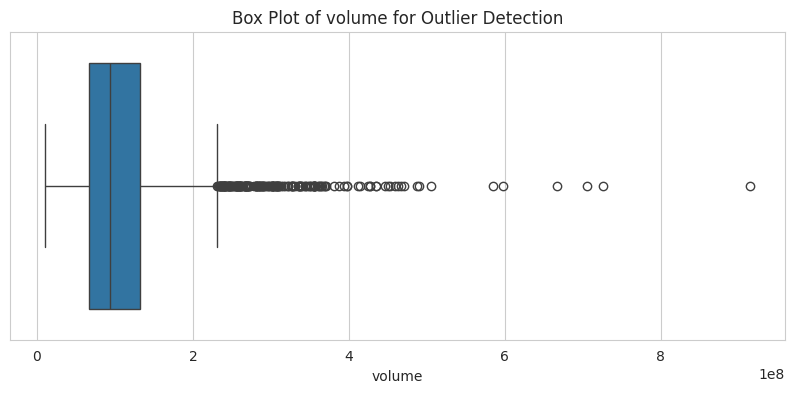

In [32]:
# Using the IQR method to detect outliers for key numerical columns

numerical_cols = ['open', 'high', 'low', 'close', 'volume']

outliers_dict = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_dict[col] = outliers

    print(f"\n--- Outliers for {col} ---")
    if not outliers.empty:
        print(f"Number of outliers: {len(outliers)}")
        display(outliers.describe())

        # Optional: Visualize outliers with a box plot
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot of {col} for Outlier Detection')
        plt.show()
    else:
        print("No outliers detected.")

## Chapter 3: Exploratory Data Analysis (EDA)

### 3.1 Historical Price Trend

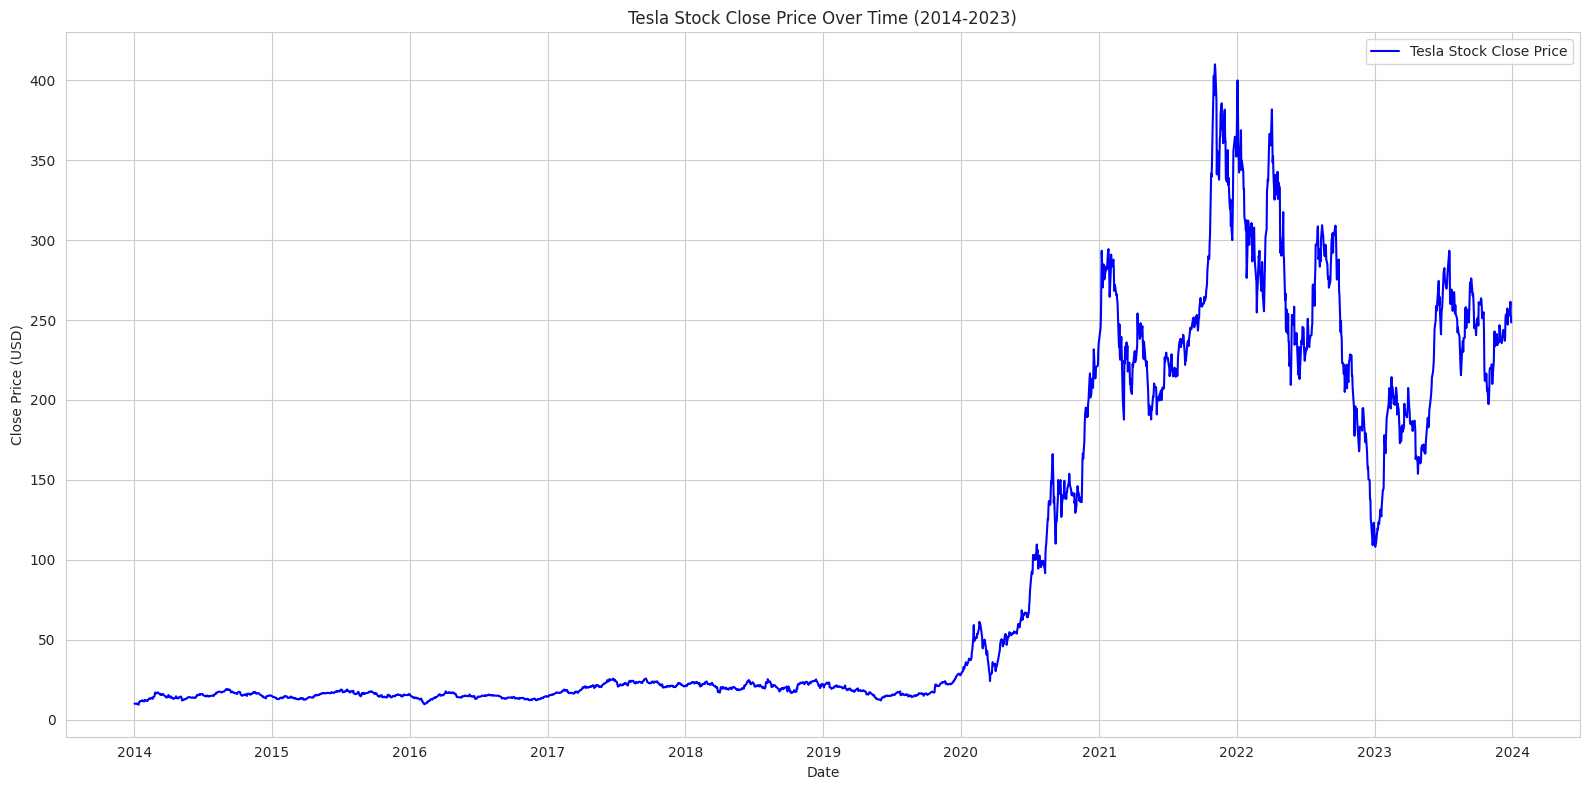

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(16, 8))
plt.plot(df['close'], label='Tesla Stock Close Price', color='blue')
plt.title('Tesla Stock Close Price Over Time (2014-2023)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2 Trading Volume Analysis

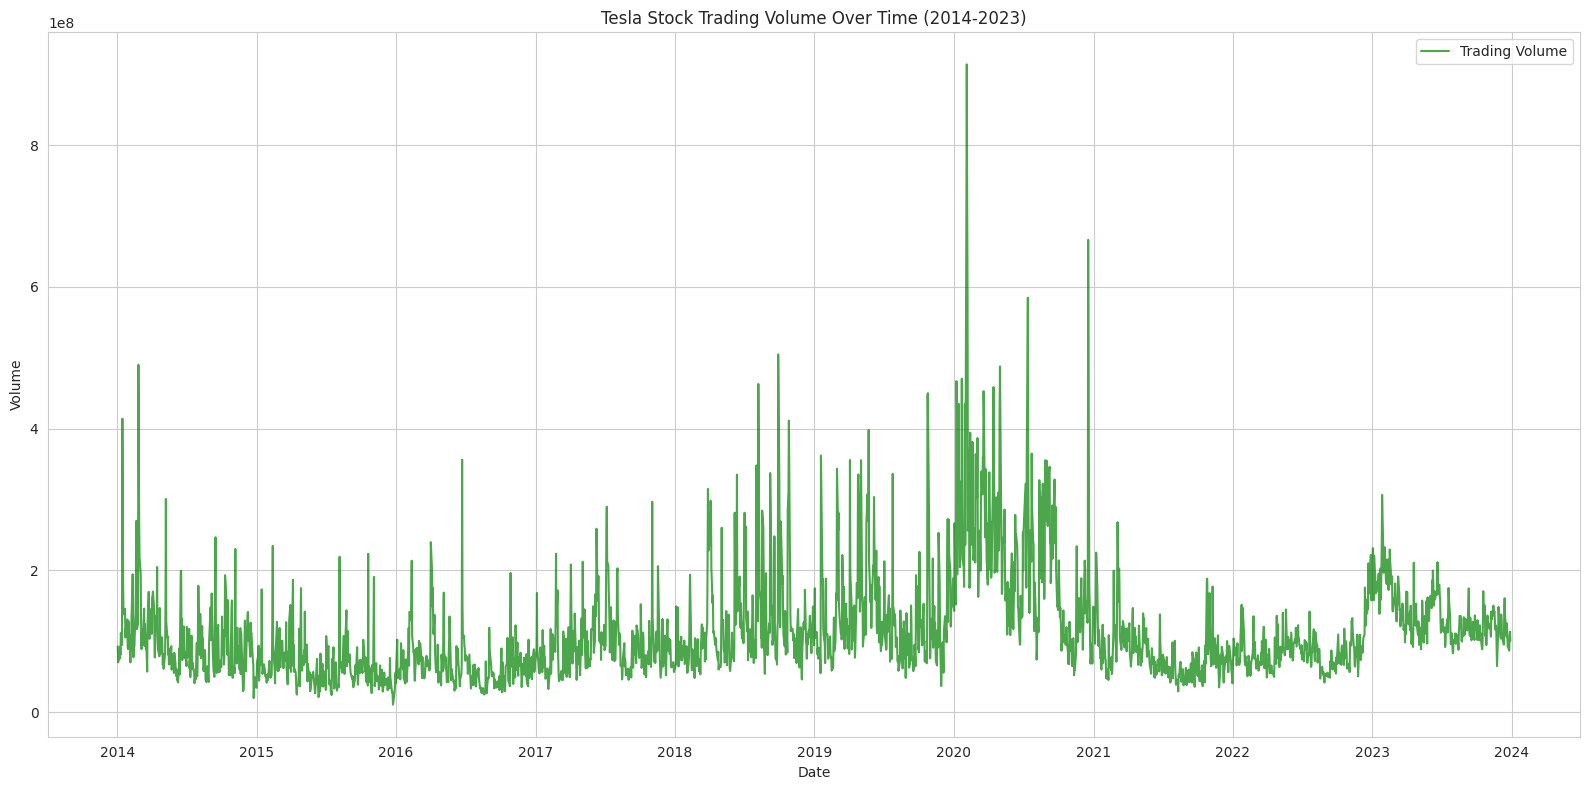

In [26]:
plt.figure(figsize=(16, 8))
plt.plot(df['volume'], label='Trading Volume', color='green', alpha=0.7)
plt.title('Tesla Stock Trading Volume Over Time (2014-2023)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

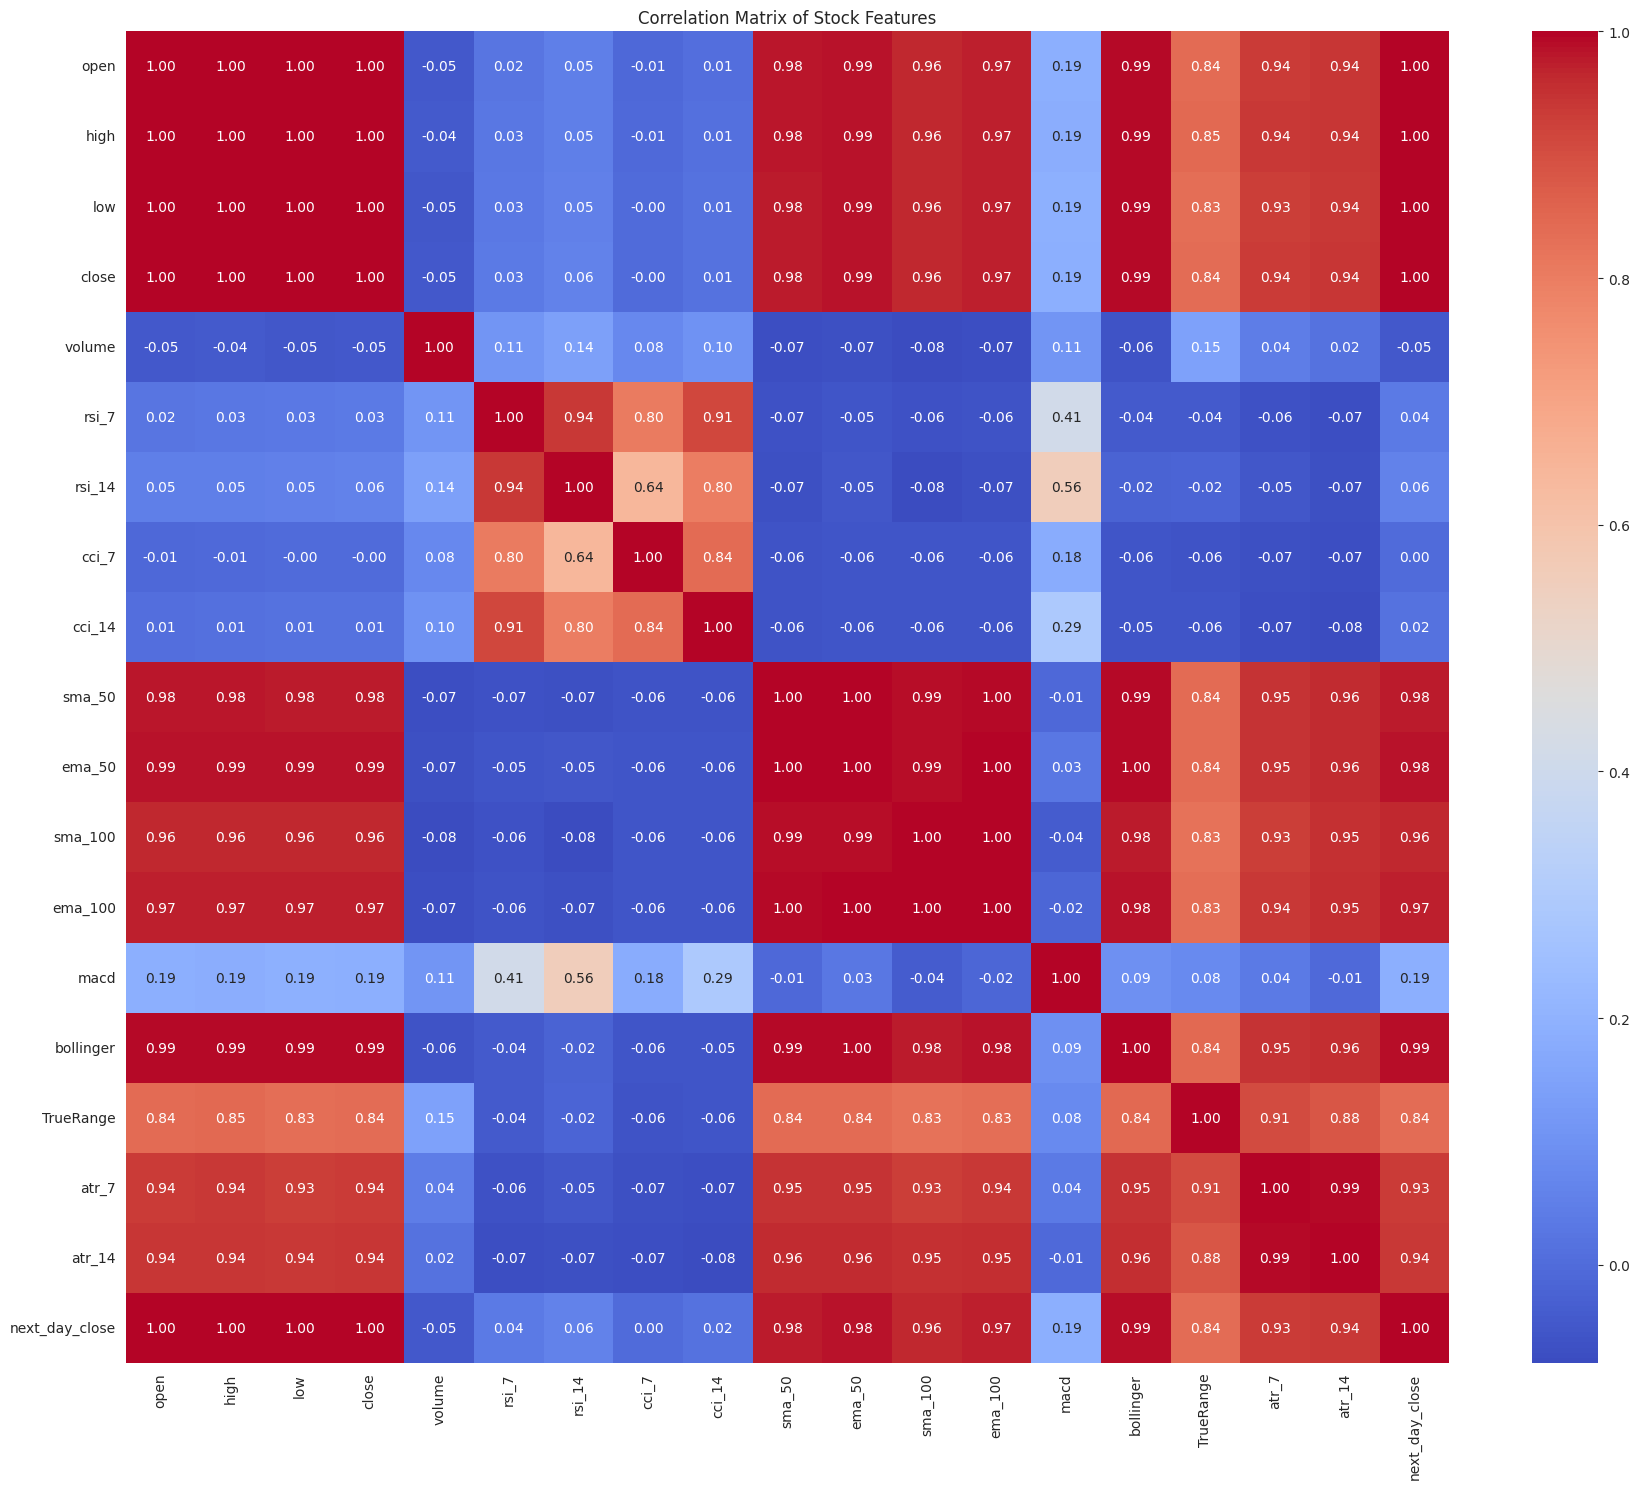

In [27]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Stock Features')
plt.tight_layout()
plt.show()

### 3.4 Technical Indicators Behavior

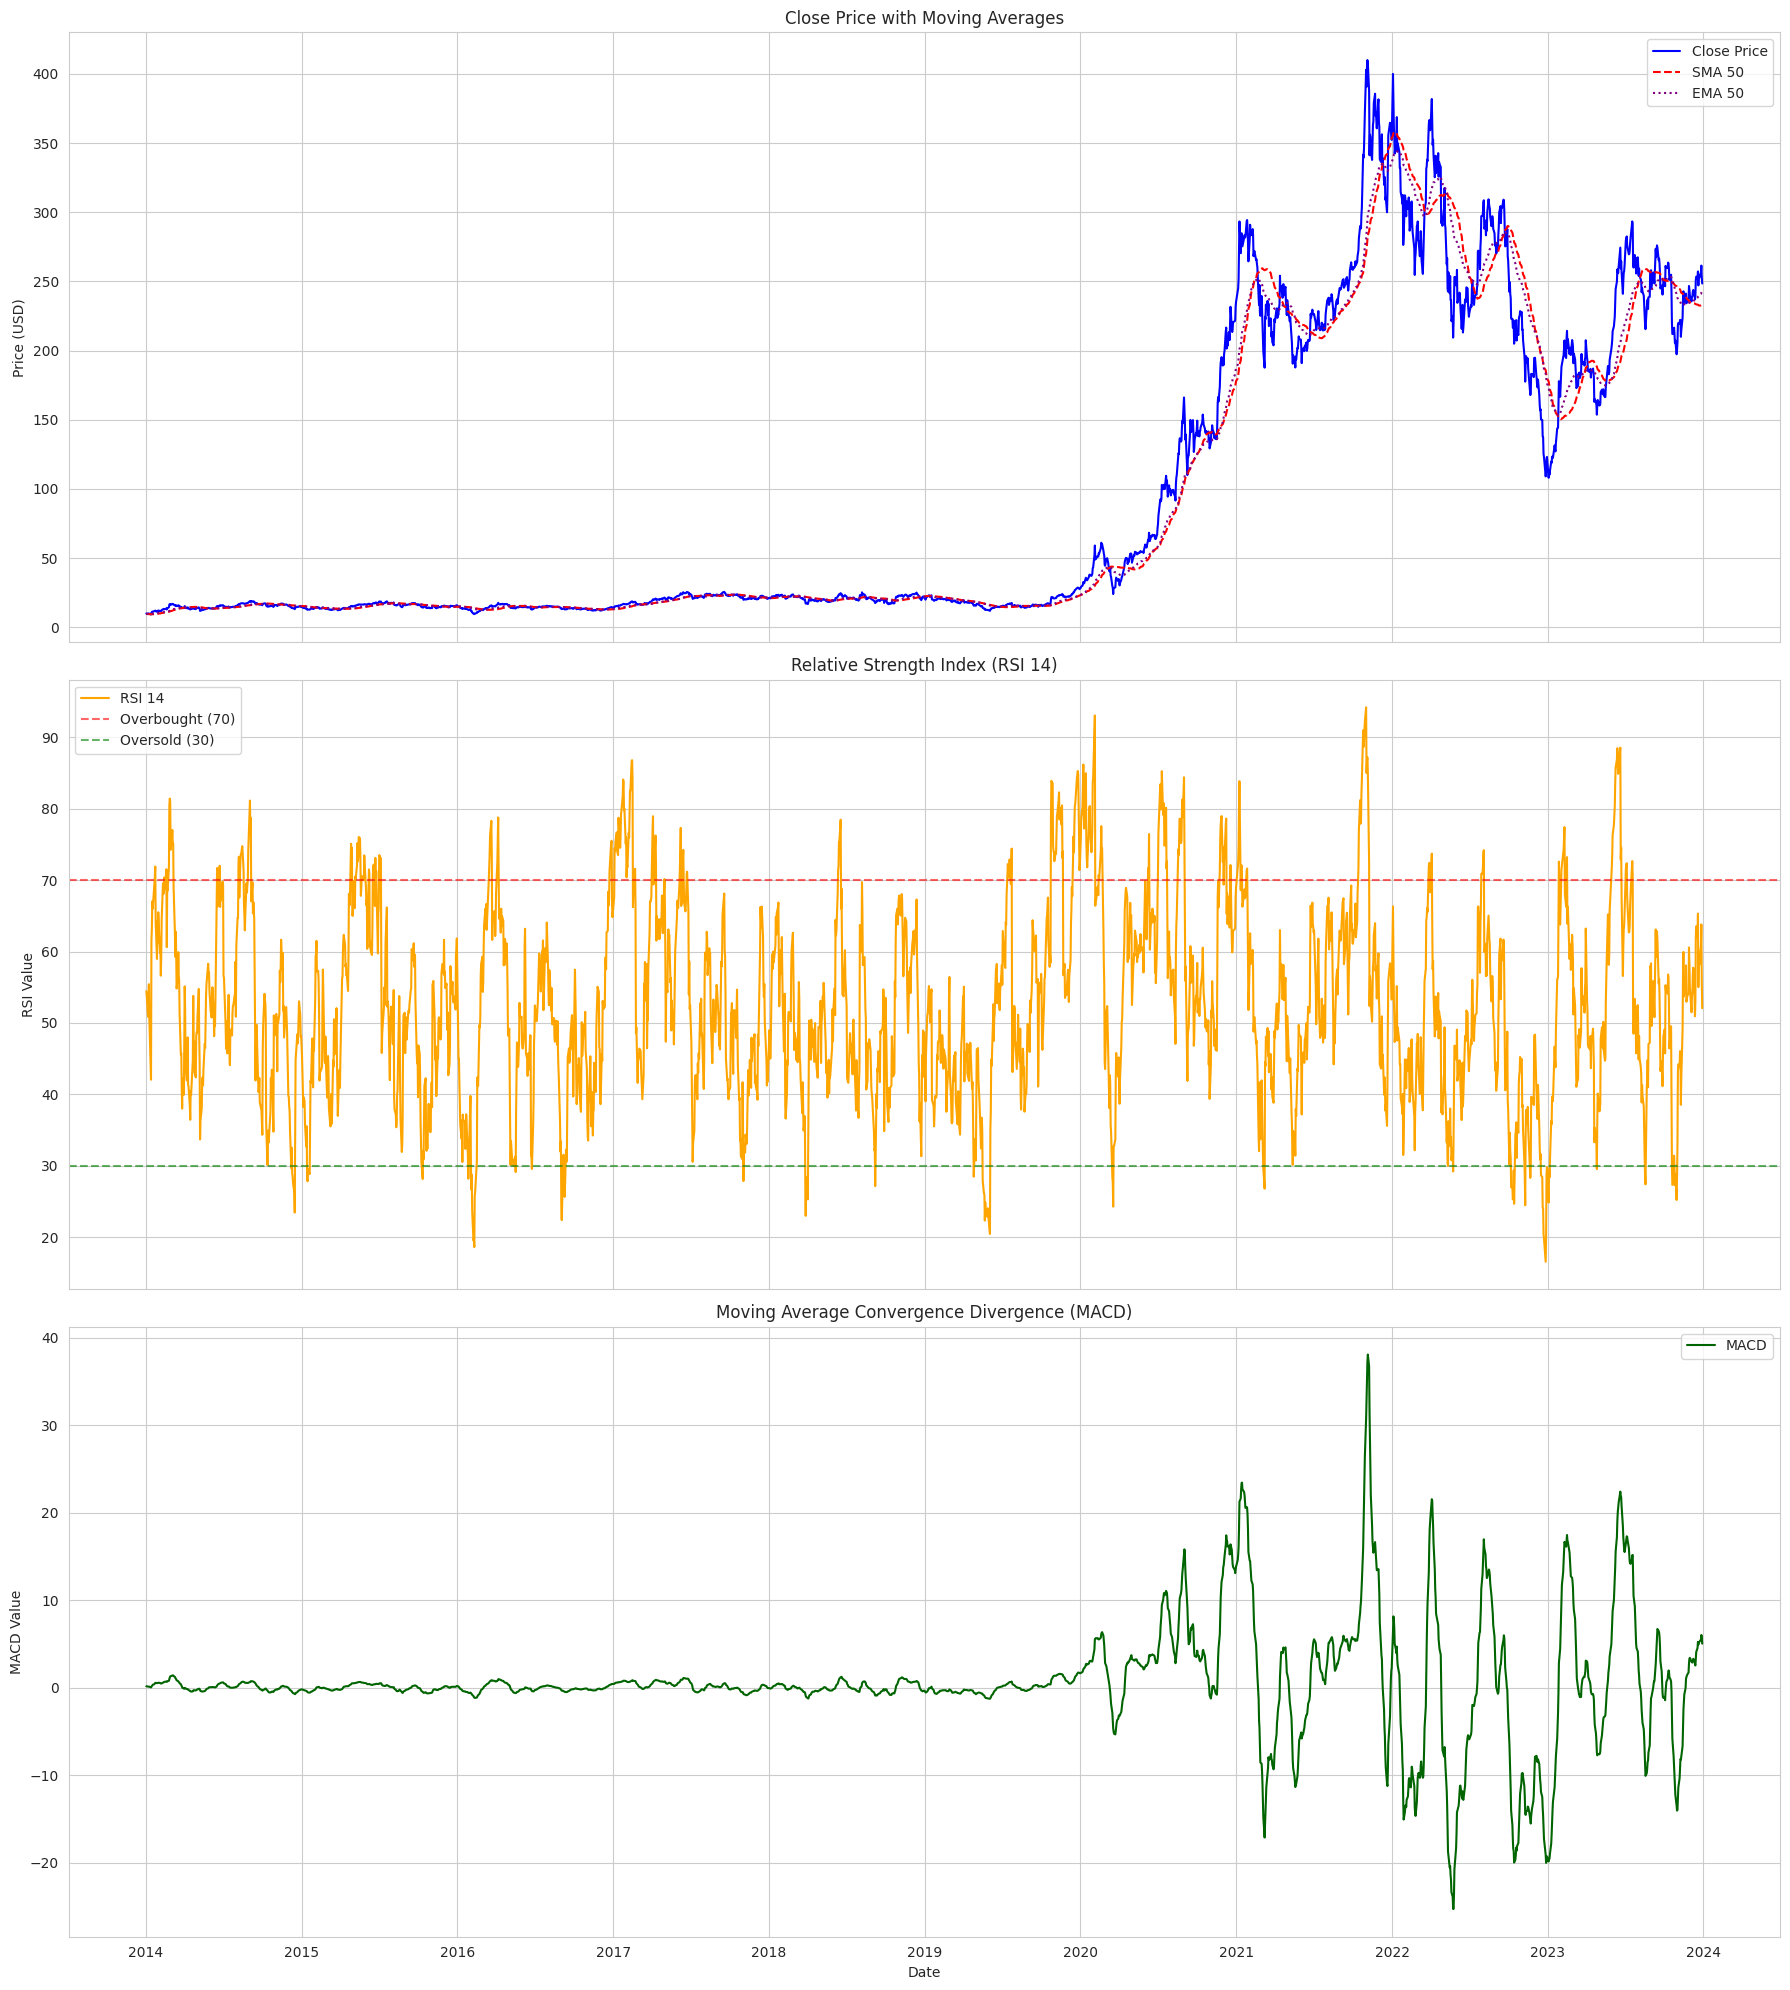

In [28]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 20), sharex=True)

# Plot Close Price with SMA/EMA
axes[0].plot(df['close'], label='Close Price', color='blue')
axes[0].plot(df['sma_50'], label='SMA 50', color='red', linestyle='--')
axes[0].plot(df['ema_50'], label='EMA 50', color='purple', linestyle=':')
axes[0].set_title('Close Price with Moving Averages')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True)

# Plot RSI
axes[1].plot(df['rsi_14'], label='RSI 14', color='orange')
axes[1].axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')
axes[1].set_title('Relative Strength Index (RSI 14)')
axes[1].set_ylabel('RSI Value')
axes[1].legend()
axes[1].grid(True)

# Plot MACD
axes[2].plot(df['macd'], label='MACD', color='darkgreen')
axes[2].set_title('Moving Average Convergence Divergence (MACD)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('MACD Value')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 3.5 Daily Returns Analysis

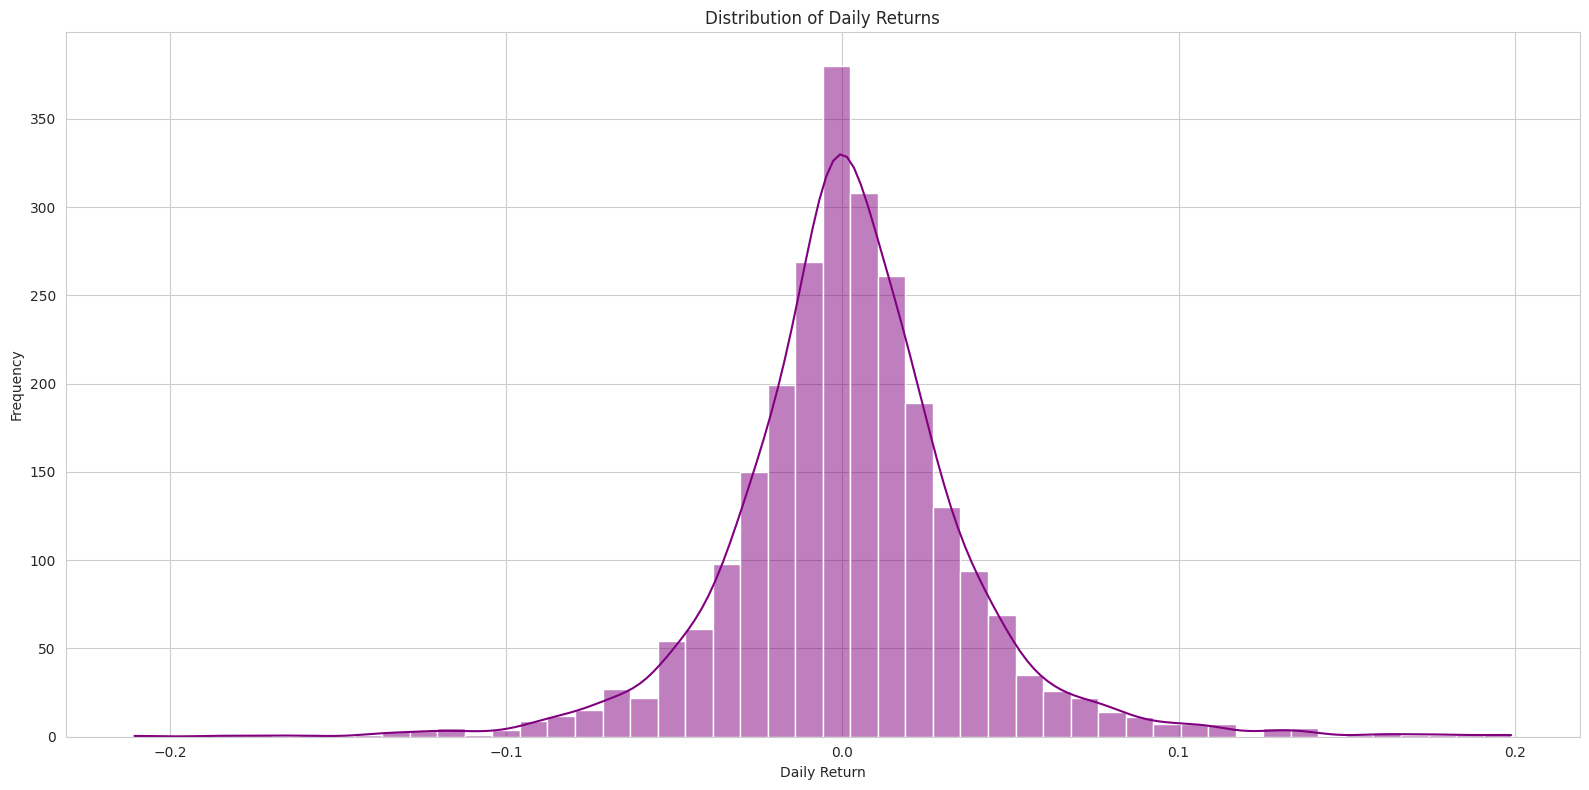

Daily Returns Summary Statistics:


,close
count,2515.000000
mean,0.001891
std,0.035063
min,-0.210628
25%,-0.015330
50%,0.001216
75%,0.018764
max,0.198949


In [29]:
daily_returns = df['close'].pct_change().dropna()

plt.figure(figsize=(16, 8))
sns.histplot(daily_returns, bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Daily Returns Summary Statistics:')
display(daily_returns.describe())

### 3.6 Rolling Averages and Volatility Analysis

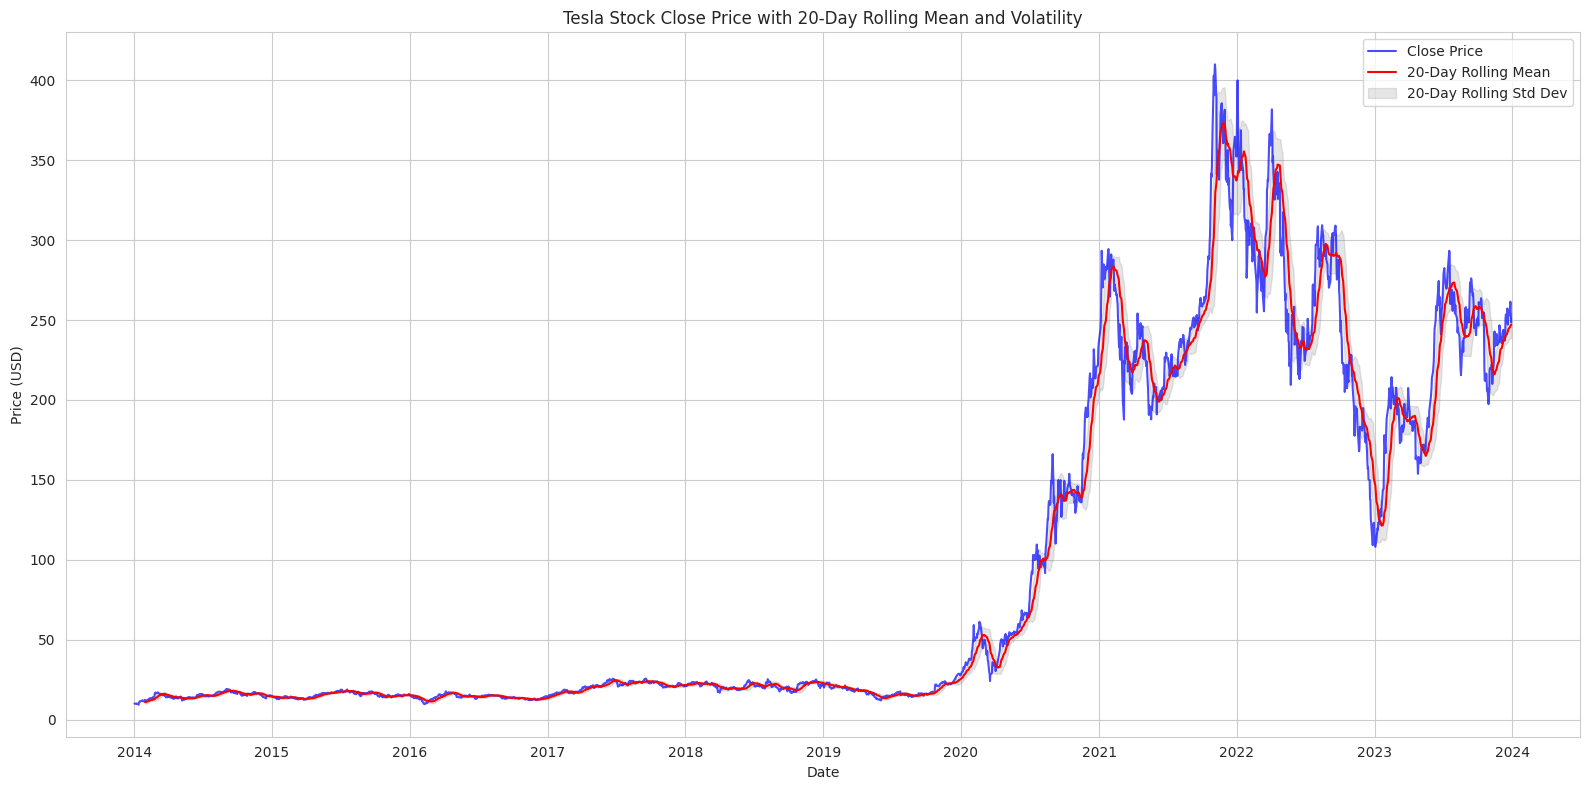

In [30]:
df['rolling_mean_20'] = df['close'].rolling(window=20).mean()
df['rolling_std_20'] = df['close'].rolling(window=20).std()

plt.figure(figsize=(16, 8))
plt.plot(df['close'], label='Close Price', color='blue', alpha=0.7)
plt.plot(df['rolling_mean_20'], label='20-Day Rolling Mean', color='red')
plt.fill_between(df.index, df['rolling_mean_20'] - df['rolling_std_20'], df['rolling_mean_20'] + df['rolling_std_20'], color='gray', alpha=0.2, label='20-Day Rolling Std Dev')
plt.title('Tesla Stock Close Price with 20-Day Rolling Mean and Volatility')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Chapter 4: Time Series Analysis

### 4.1 Stationarity Testing (ADF Test)

In [33]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC') # .dropna() handles NaNs from differencing
    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label}: {value:.4f}')
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis (Ho), reject the null hypothesis. Data has no unit root and is stationary.")
    else:
        print("Weak evidence against null hypothesis, fail to reject the null hypothesis. Data has a unit root and is non-stationary.")

# Perform ADF test on the 'close' price
adf_test(df['close'], title='Tesla Close Price')

Augmented Dickey-Fuller Test: Tesla Close Price
ADF Test Statistic: -1.0420
p-value: 0.7376
#Lags Used: 27.0000
Number of Observations Used: 2488.0000
Weak evidence against null hypothesis, fail to reject the null hypothesis. Data has a unit root and is non-stationary.


### 4.2 Differencing if Needed

In [34]:
# Apply first-order differencing to the 'close' price
df['close_diff'] = df['close'].diff().dropna()

print("First-order differencing applied to 'close' price.")
display(df[['close', 'close_diff']].head())

# Perform ADF test on the differenced series
adf_test(df['close_diff'], title='Tesla Close Price (Differenced)')

First-order differencing applied to 'close' price.


,close,close_diff
date,,
2014-01-02,10.006667,NaN
2014-01-03,9.970667,-0.036000
2014-01-06,9.800000,-0.170667
2014-01-07,9.957333,0.157333
2014-01-08,10.085333,0.128000


Augmented Dickey-Fuller Test: Tesla Close Price (Differenced)
ADF Test Statistic: -10.0597
p-value: 0.0000
#Lags Used: 27.0000
Number of Observations Used: 2487.0000
Strong evidence against the null hypothesis (Ho), reject the null hypothesis. Data has no unit root and is stationary.


### 4.3 ACF & PACF Analysis

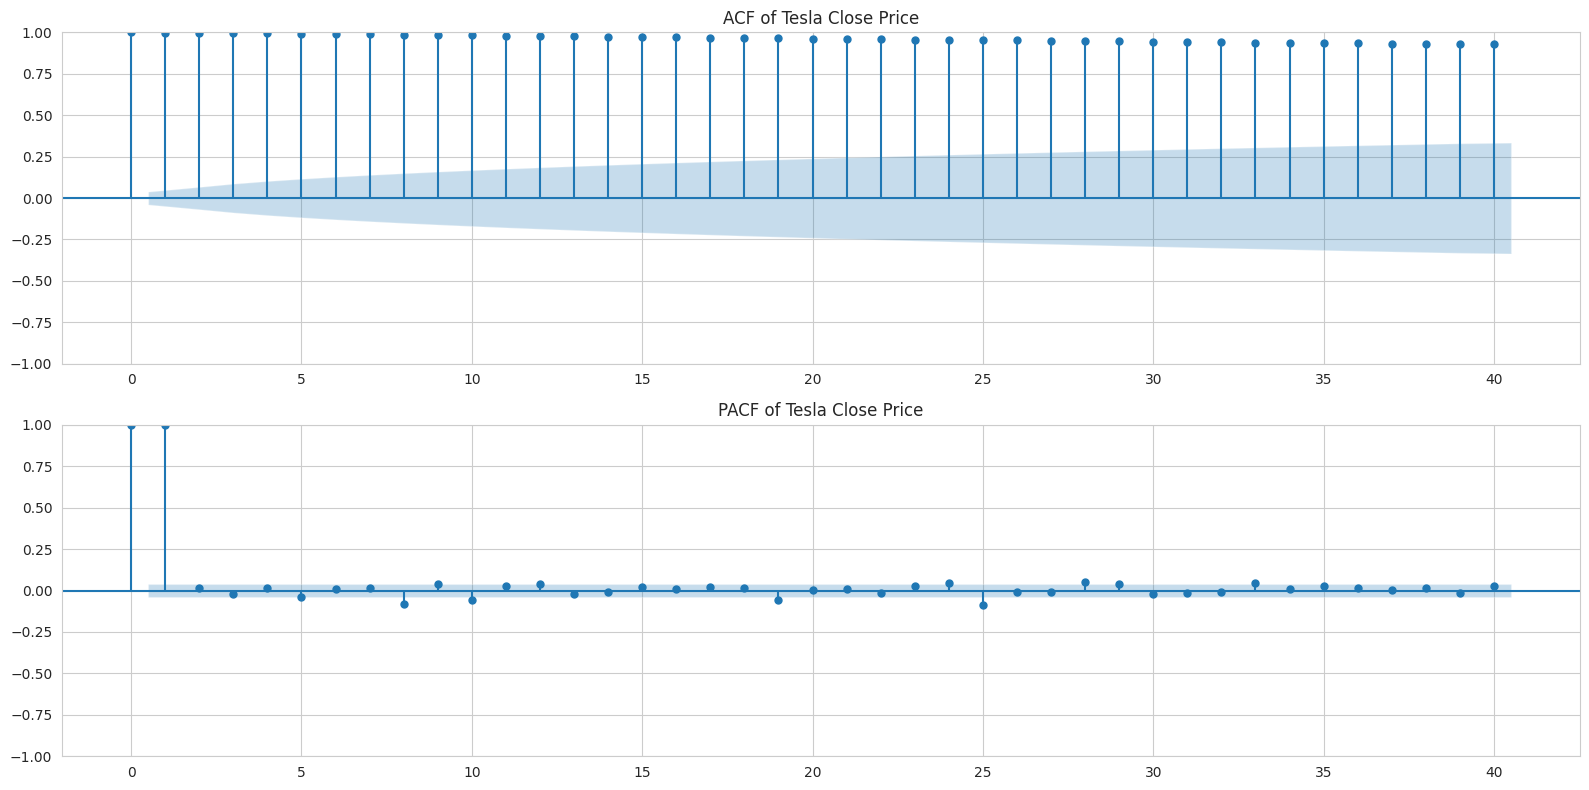

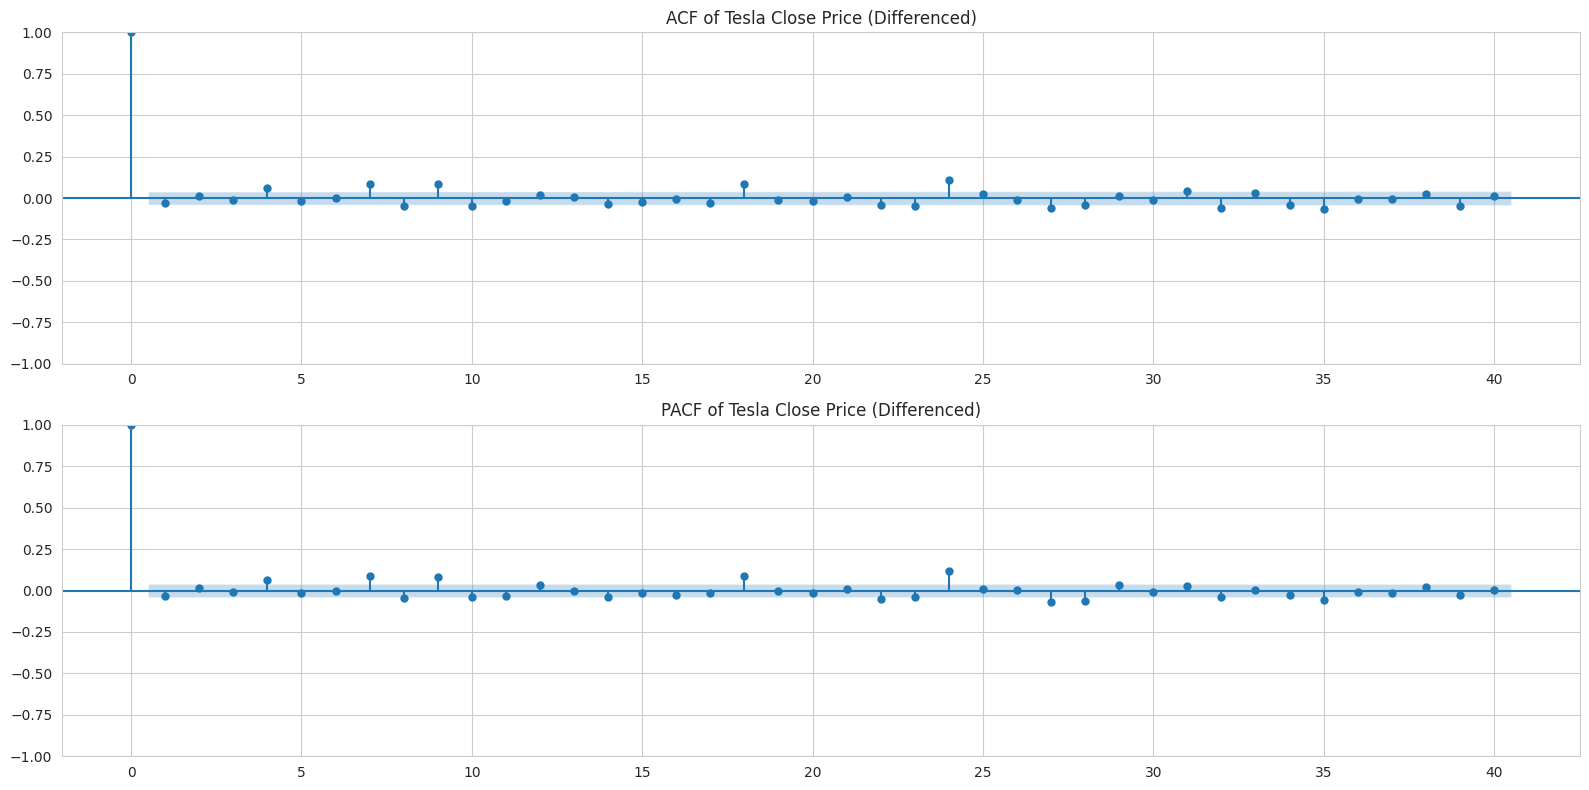

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the original 'close' price
plt.figure(figsize=(16, 8))
plt.subplot(211)
plot_acf(df['close'], ax=plt.gca(), lags=40)
plt.title('ACF of Tesla Close Price')
plt.subplot(212)
plot_pacf(df['close'], ax=plt.gca(), lags=40)
plt.title('PACF of Tesla Close Price')
plt.tight_layout()
plt.show()

# Plot ACF and PACF for the differenced 'close' price
plt.figure(figsize=(16, 8))
plt.subplot(211)
plot_acf(df['close_diff'].dropna(), ax=plt.gca(), lags=40)
plt.title('ACF of Tesla Close Price (Differenced)')
plt.subplot(212)
plot_pacf(df['close_diff'].dropna(), ax=plt.gca(), lags=40)
plt.title('PACF of Tesla Close Price (Differenced)')
plt.tight_layout()
plt.show()

### 4.4 Seasonal Decomposition

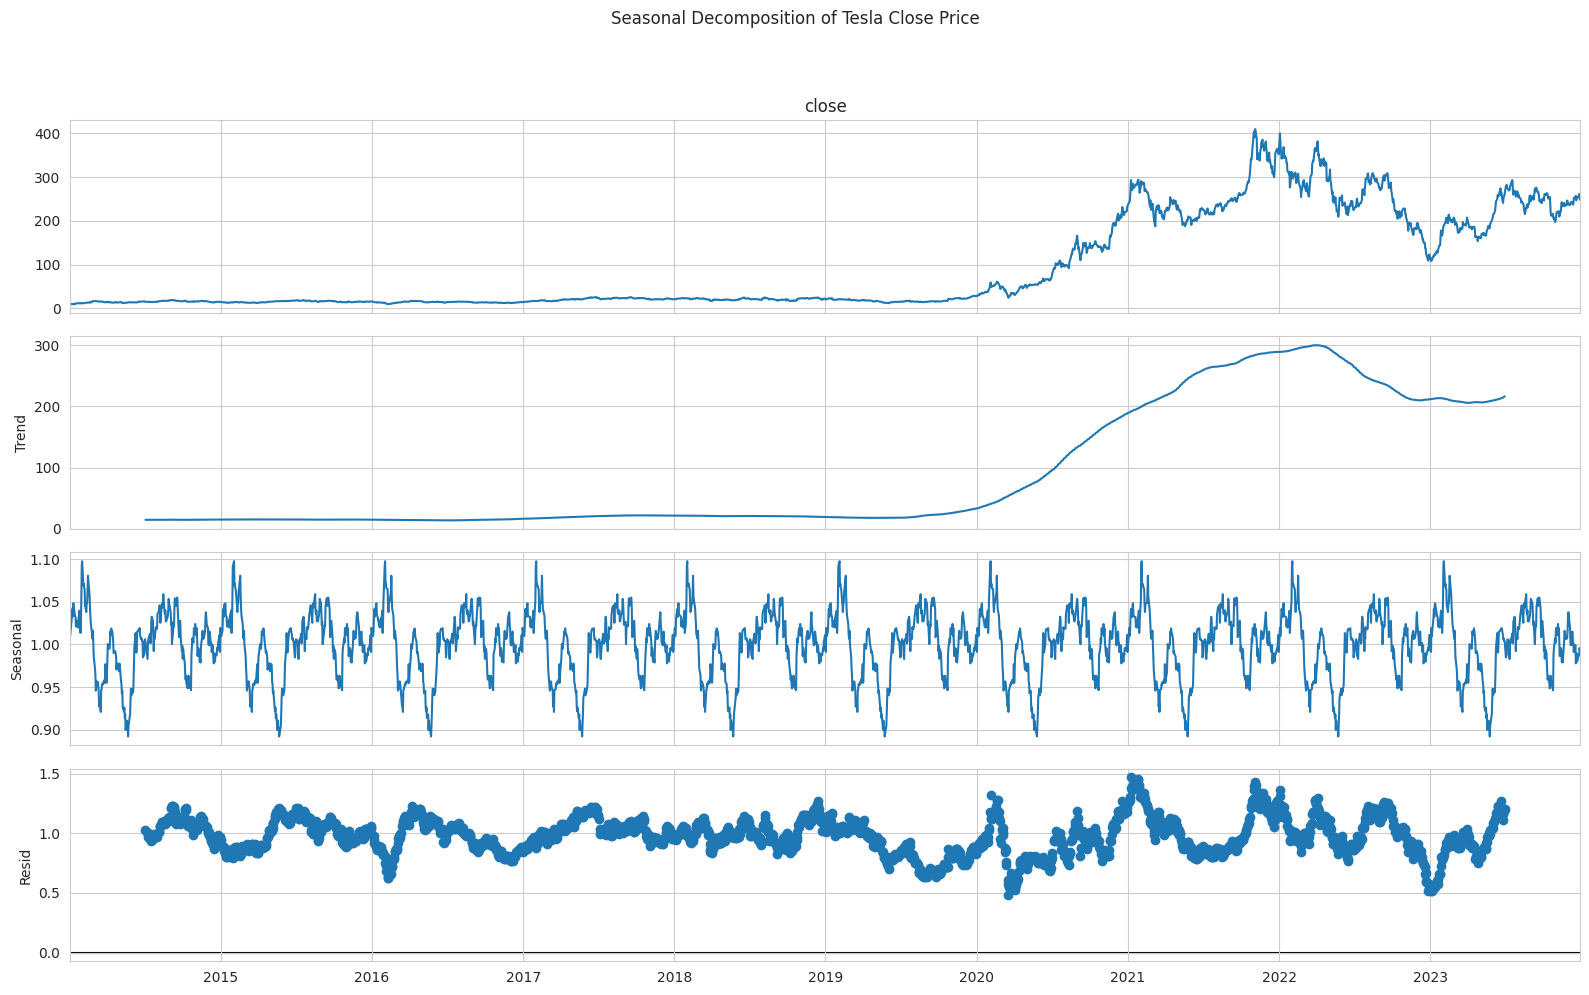

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition on the 'close' price
# Assuming a multiplicative model as stock prices tend to grow/decline proportionally over time.
# Using a period of 252 (approximate number of trading days in a year) for yearly seasonality.
# If data frequency is not daily, adjust the period accordingly.

decomposition = seasonal_decompose(df['close'], model='multiplicative', period=252)

fig = decomposition.plot()
fig.set_size_inches(16, 10)
plt.suptitle('Seasonal Decomposition of Tesla Close Price', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Chapter 5: Model Evaluation

### 5.1 Baseline LSTM Model Evaluation

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate MSE and RMSE on inverse-scaled data
mse = mean_squared_error(y_test_inverse_scaled, predictions_inverse_scaled)
rmse = np.sqrt(mse)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

Mean Squared Error (MSE): 4060705049.9126
Root Mean Squared Error (RMSE): 63723.6616


### 5.2 Visualization of Predictions vs. Actuals

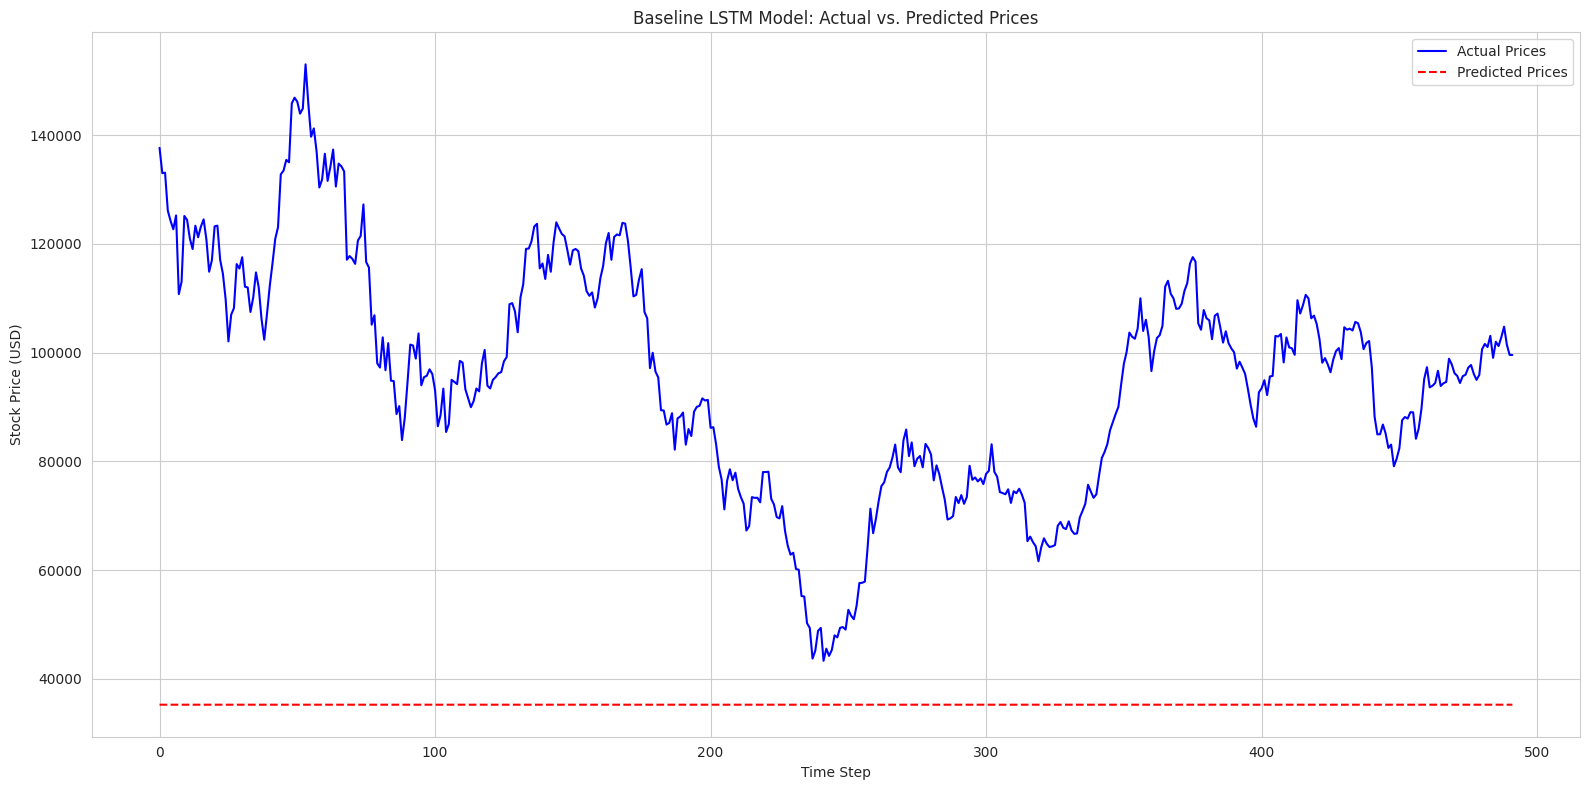

In [38]:
plt.figure(figsize=(16, 8))
plt.plot(y_test_inverse_scaled, label='Actual Prices', color='blue')
plt.plot(predictions_inverse_scaled, label='Predicted Prices', color='red', linestyle='--')
plt.title('Baseline LSTM Model: Actual vs. Predicted Prices')
plt.xlabel('Time Step')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Chapter 6: Feature Engineering

### 6.1 Creating Lagged Features

Lagged features are past values of a time series that are used as input features to predict future values. For our LSTM model, incorporating lagged values of the 'close' price will help the model learn patterns and dependencies over time.

In [11]:
# Create lagged features for the 'close' price
# We'll create lags for the past 1, 2, 3, 5, and 10 days

for i in [1, 2, 3, 5, 10]:
    df[f'close_lag_{i}'] = df['close'].shift(i)

# Drop rows with NaN values resulting from creating lagged features
# These NaNs appear at the beginning of the DataFrame
df_fe = df.dropna().copy()

print("Lagged features created and NaN rows removed.")
display(df_fe.head())

Lagged features created and NaN rows removed.


,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,...,bollinger,TrueRange,atr_7,atr_14,next_day_close,close_lag_1,close_lag_2,close_lag_3,close_lag_5,close_lag_10
date,,,,,,,,,,,,,,,,,,,,,
2014-01-16,10.833333,11.513333,10.826667,11.398000,179391000,75.369106,67.033660,127.426225,232.864672,9.500040,...,10.042167,0.686666,0.627412,0.547024,11.334000,10.942000,10.751333,9.289333,9.835333,10.006667
2014-01-17,11.346000,11.546667,11.196667,11.334000,138093000,73.270469,65.998115,90.582402,175.486472,9.490973,...,10.115600,0.350000,0.587782,0.532951,11.778667,11.398000,10.942000,10.751333,9.714667,9.970667
2014-01-21,11.416000,11.819333,11.387333,11.778667,146020500,78.192566,69.521129,86.927814,154.131350,9.525000,...,10.235467,0.485333,0.573147,0.529549,11.904000,11.334000,11.398000,10.942000,9.289333,9.800000
2014-01-22,11.854000,12.021333,11.650667,11.904000,105339000,79.437678,70.450475,88.902773,132.754462,9.576720,...,10.353200,0.370666,0.544221,0.518201,12.100000,11.778667,11.334000,11.398000,10.751333,9.957333
2014-01-23,11.815333,12.158667,11.561333,12.100000,118011000,81.377569,71.893773,95.675937,112.464472,9.634787,...,10.479700,0.597334,0.551808,0.523853,11.640000,11.904000,11.778667,11.334000,10.942000,10.085333


### 6.2 Feature Scaling and Sequence Generation

To prepare the data for the LSTM model, we need to scale the features to a range between 0 and 1. After scaling, we will transform the data into sequences suitable for LSTM input, using a sliding window approach. Finally, we'll split the data into training and testing sets, ensuring the temporal order is preserved.

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Define the features (X) and target (y)
# All columns except 'next_day_close' will be features
features = df_fe.drop(columns=['next_day_close']).columns
target = 'next_day_close'

X_data = df_fe[features].values
y_data = df_fe[target].values.reshape(-1, 1) # Reshape for scaler

# Scale the features and the target variable separately
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaled_X = scaler_X.fit_transform(X_data)

scaler_y = MinMaxScaler(feature_range=(0, 1))
scaled_y = scaler_y.fit_transform(y_data)

print("Features and target scaled successfully.")
print(f"Shape of scaled_X: {scaled_X.shape}")
print(f"Shape of scaled_y: {scaled_y.shape}")

Features and target scaled successfully.
Shape of scaled_X: (2506, 23)
Shape of scaled_y: (2506, 1)


In [13]:
# Function to create sequences for LSTM
def create_sequences(X, y, look_back=60):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i + look_back)])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)

# Define look_back period
look_back = 60

# Create sequences from the scaled data
X, y = create_sequences(scaled_X, scaled_y, look_back)

print(f"Sequences created with look_back = {look_back}.")
print(f"Shape of X (features sequences): {X.shape}")
print(f"Shape of y (target sequences): {y.shape}")

Sequences created with look_back = 60.
Shape of X (features sequences): (2446, 60, 23)
Shape of y (target sequences): (2446, 1)


In [14]:
# Time-based train-test split (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print("Data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets.
Shape of X_train: (1956, 60, 23)
Shape of y_train: (1956, 1)
Shape of X_test: (490, 60, 23)
Shape of y_test: (490, 1)


## Chapter 7: LSTM Model with Engineered Features

### 7.1 Building the LSTM Model

We will construct an LSTM model using Keras, similar to the previous baseline model, but now it will receive the input with our newly engineered features. The architecture will consist of LSTM layers followed by Dense layers for output.

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model architecture with updated unit counts
model_fe = Sequential()
model_fe.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_fe.add(Dropout(0.2))
model_fe.add(LSTM(units=64, return_sequences=False))
model_fe.add(Dropout(0.2))
model_fe.add(Dense(units=1)) # Output layer for predicting the next day's close price

# Compile the model
model_fe.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM model with engineered features built and compiled.")
model_fe.summary()

LSTM model with engineered features built and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        79,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,833 (503.25 KB)

 Trainable params: 128,833 (503.25 KB)

 Non-trainable params: 0 (0.00 B)

### 7.2 Training the LSTM Model

Now we will train the new LSTM model using the `X_train` and `y_train` datasets, which include the scaled and sequenced engineered features.

In [46]:
history_fe = model_fe.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("LSTM model with engineered features trained successfully.")

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0043 - val_loss: 0.0149
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0011 - val_loss: 0.0100
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 7.9222e-04 - val_loss: 0.0058
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 9.1748e-04 - val_loss: 0.0116
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 8.0432e-04 - val_loss: 0.0075
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 6.1572e-04 - val_loss: 0.0060
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.3975e-04 - val_loss: 0.0062
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 5.8346e-04 - val_loss: 0.0069
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 5.1562e-04 - val_loss: 0.0047
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 4.2736e-04 - val_loss: 0.0047
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.8783e-04 - val_loss: 0.0057
Epoch 12/50
55/55 ━━━━━━━━━

### 7.3 Evaluating the LSTM Model with Engineered Features

After training, we evaluate the model's performance on the test set. This involves making predictions, inverse scaling them to the original price range, and calculating metrics like Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Make predictions on the test data
predictions_fe_scaled = model_fe.predict(X_test)

# Inverse transform the predictions and actual values to original scale
predictions_fe_inverse_scaled = scaler_y.inverse_transform(predictions_fe_scaled)
y_test_fe_inverse_scaled = scaler_y.inverse_transform(y_test)

# Calculate MSE and RMSE
mse_fe = mean_squared_error(y_test_fe_inverse_scaled, predictions_fe_inverse_scaled)
rmse_fe = np.sqrt(mse_fe)

print(f'LSTM Model with Engineered Features - Mean Squared Error (MSE): {mse_fe:.4f}')
print(f'LSTM Model with Engineered Features - Root Mean Squared Error (RMSE): {rmse_fe:.4f}')


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
LSTM Model with Engineered Features - Mean Squared Error (MSE): 363.7967
LSTM Model with Engineered Features - Root Mean Squared Error (RMSE): 19.0735


### 7.4 Visualization of Predictions vs. Actuals (Engineered Features Model)

Visualizing the predictions against the actual prices helps us understand how well the model captures the trends and fluctuations in the stock prices.

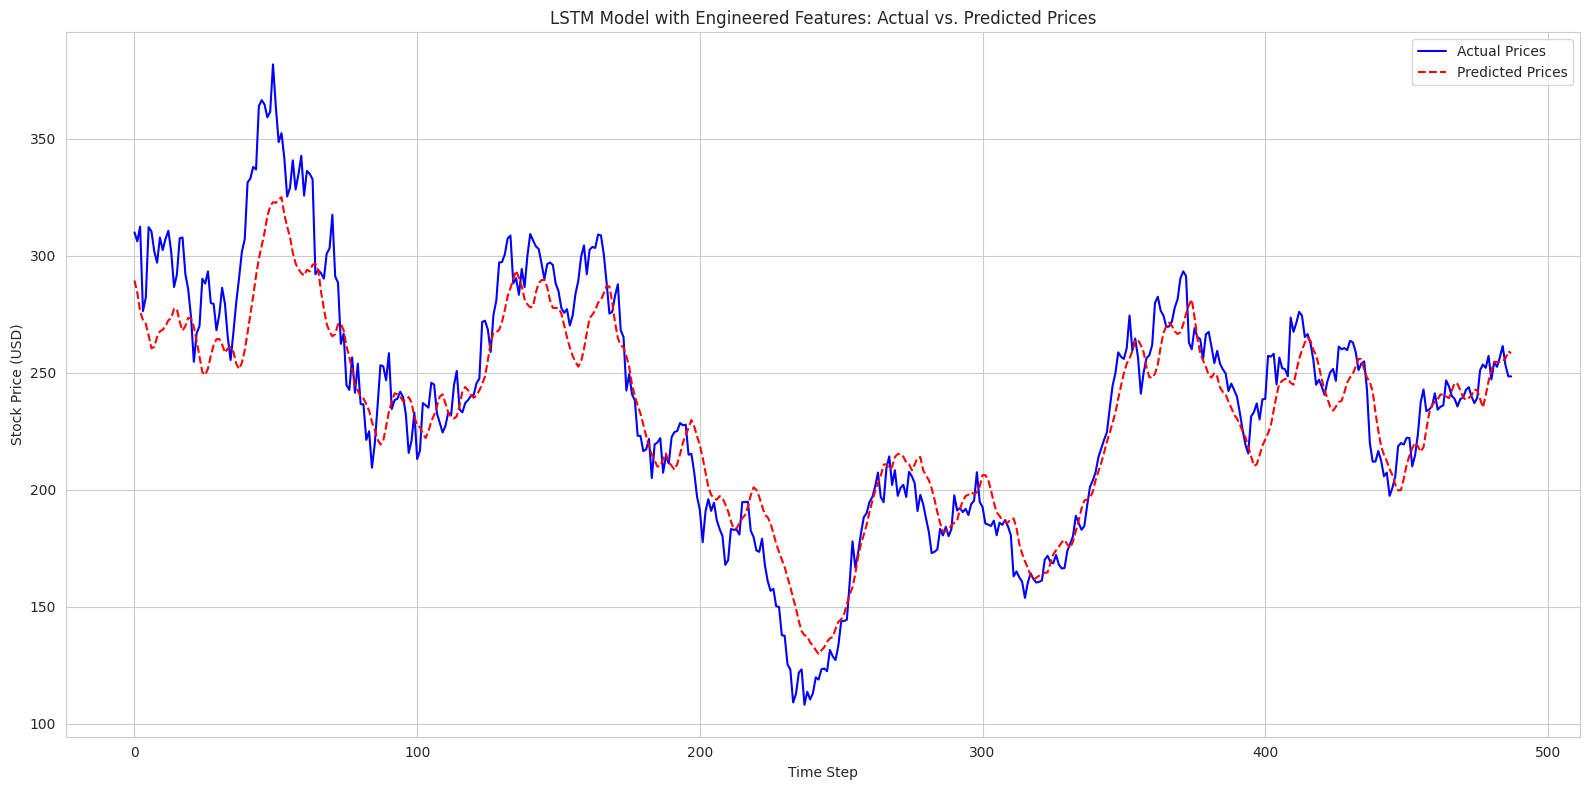

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(y_test_fe_inverse_scaled, label='Actual Prices', color='blue')
plt.plot(predictions_fe_inverse_scaled, label='Predicted Prices', color='red', linestyle='--')
plt.title('LSTM Model with Engineered Features: Actual vs. Predicted Prices')
plt.xlabel('Time Step')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 7.3 Evaluating the LSTM Model with Engineered Features

After training, we evaluate the model's performance on the test set. This involves making predictions, inverse scaling them to the original price range, and calculating metrics like Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

In [47]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Make predictions on the test data
predictions_fe_scaled = model_fe.predict(X_test)

# Inverse transform the predictions and actual values to original scale
predictions_fe_inverse_scaled = scaler_y.inverse_transform(predictions_fe_scaled)
y_test_fe_inverse_scaled = scaler_y.inverse_transform(y_test)

# Calculate MSE and RMSE
mse_fe = mean_squared_error(y_test_fe_inverse_scaled, predictions_fe_inverse_scaled)
rmse_fe = np.sqrt(mse_fe)

print(f'LSTM Model with Engineered Features - Mean Squared Error (MSE): {mse_fe:.4f}')
print(f'LSTM Model with Engineered Features - Root Mean Squared Error (RMSE): {rmse_fe:.4f}')


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
LSTM Model with Engineered Features - Mean Squared Error (MSE): 363.7967
LSTM Model with Engineered Features - Root Mean Squared Error (RMSE): 19.0735


### 7.4 Visualization of Predictions vs. Actuals (Engineered Features Model)

Visualizing the predictions against the actual prices helps us understand how well the model captures the trends and fluctuations in the stock prices.

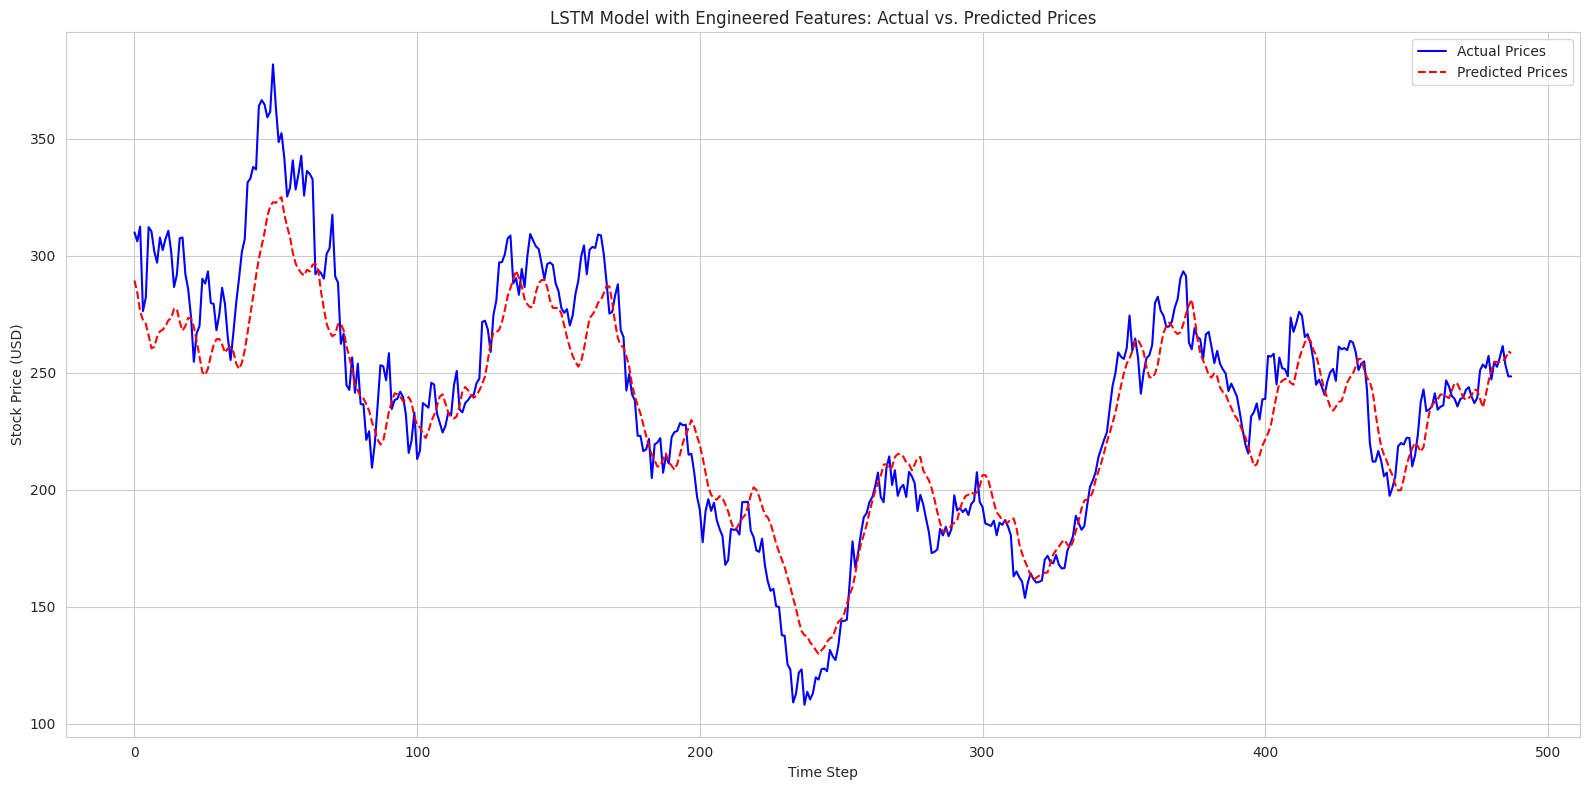

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(y_test_fe_inverse_scaled, label='Actual Prices', color='blue')
plt.plot(predictions_fe_inverse_scaled, label='Predicted Prices', color='red', linestyle='--')
plt.title('LSTM Model with Engineered Features: Actual vs. Predicted Prices')
plt.xlabel('Time Step')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Chapter 7: LSTM Model with Engineered Features

### 7.1 Building the LSTM Model

We will construct an LSTM model using Keras, similar to the previous baseline model, but now it will receive the input with our newly engineered features. The architecture will consist of LSTM layers followed by Dense layers for output.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model architecture with updated unit counts
model_fe = Sequential()
model_fe.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_fe.add(Dropout(0.2))
model_fe.add(LSTM(units=64, return_sequences=False))
model_fe.add(Dropout(0.2))
model_fe.add(Dense(units=1)) # Output layer for predicting the next day's close price

# Compile the model
model_fe.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM model with engineered features built and compiled.")
model_fe.summary()

LSTM model with engineered features built and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,297 (497.25 KB)

 Trainable params: 127,297 (497.25 KB)

 Non-trainable params: 0 (0.00 B)

### 7.2 Training the LSTM Model

Now we will train the new LSTM model using the `X_train` and `y_train` datasets, which include the scaled and sequenced engineered features.

In [16]:
history_fe = model_fe.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("LSTM model with engineered features trained successfully.")

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0038 - val_loss: 0.0051
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 9.0238e-04 - val_loss: 0.0097
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 7.9039e-04 - val_loss: 0.0038
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 5.7598e-04 - val_loss: 0.0098
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 6.3076e-04 - val_loss: 0.0038
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 5.0790e-04 - val_loss: 0.0039
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 6.7572e-04 - val_loss: 0.0068
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 6.3079e-04 - val_loss: 0.0039
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 4.5317e-04 - val_loss: 0.0038
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 5.1403e-04 - val_loss: 0.0037
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 5.2363e-04 - val_loss: 0.0032
Epoch 12/50
55/5

### 7.3 Training History of the Updated LSTM Model

Let's visualize the training and validation loss over epochs for the LSTM model with the updated architecture to understand its learning process.

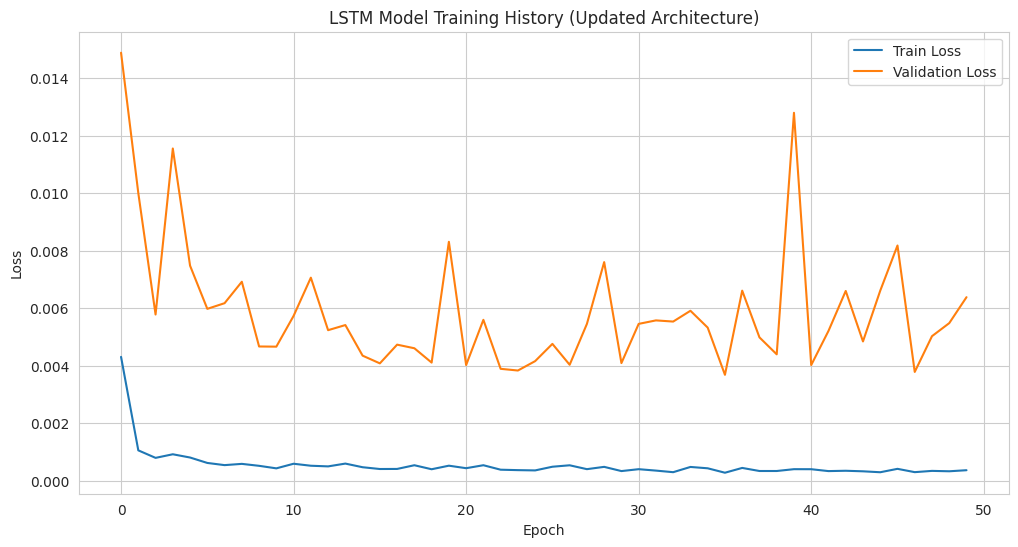

In [53]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_fe.history['loss'], label='Train Loss')
plt.plot(history_fe.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training History (Updated Architecture)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 7.4 Additional Evaluation Metrics

Beyond MSE and RMSE, let's look at Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), and R-squared to further evaluate the model's predictive accuracy.

In [54]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Calculate Mean Absolute Error (MAE)
mae_fe = mean_absolute_error(y_test_fe_inverse_scaled, predictions_fe_inverse_scaled)
print(f'LSTM Model with Engineered Features - Mean Absolute Error (MAE): {mae_fe:.4f}')

# Calculate Mean Absolute Percentage Error (MAPE)
# Avoid division by zero by adding a small epsilon to actual values if they can be zero
mape_fe = np.mean(np.abs((y_test_fe_inverse_scaled - predictions_fe_inverse_scaled) / (y_test_fe_inverse_scaled + 1e-8))) * 100
print(f'LSTM Model with Engineered Features - Mean Absolute Percentage Error (MAPE): {mape_fe:.4f}%')

# Calculate R-squared (R2 Score)
r2_fe = r2_score(y_test_fe_inverse_scaled, predictions_fe_inverse_scaled)
print(f'LSTM Model with Engineered Features - R-squared (R2 Score): {r2_fe:.4f}')

LSTM Model with Engineered Features - Mean Absolute Error (MAE): 14.2931
LSTM Model with Engineered Features - Mean Absolute Percentage Error (MAPE): 6.0667%
LSTM Model with Engineered Features - R-squared (R2 Score): 0.8682


#### Interpretation of Metrics:

*   **Mean Absolute Error (MAE):** This is the average of the absolute differences between predictions and actual observations. It gives an idea of the typical magnitude of errors in the same units as the target variable.
*   **Mean Absolute Percentage Error (MAPE):** This expresses the accuracy as a percentage. It is useful for understanding the error in relative terms, making it suitable for comparing forecasts of different scales.
*   **R-squared (R2 Score):** This statistical measure represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model. An R2 score of 1 indicates that the model explains all the variability of the response data around its mean.

### 7.5 Visualizing Prediction Errors

To understand the nature of our model's errors, we will visualize the residuals (actual - predicted values) and create a scatter plot comparing actual versus predicted prices.

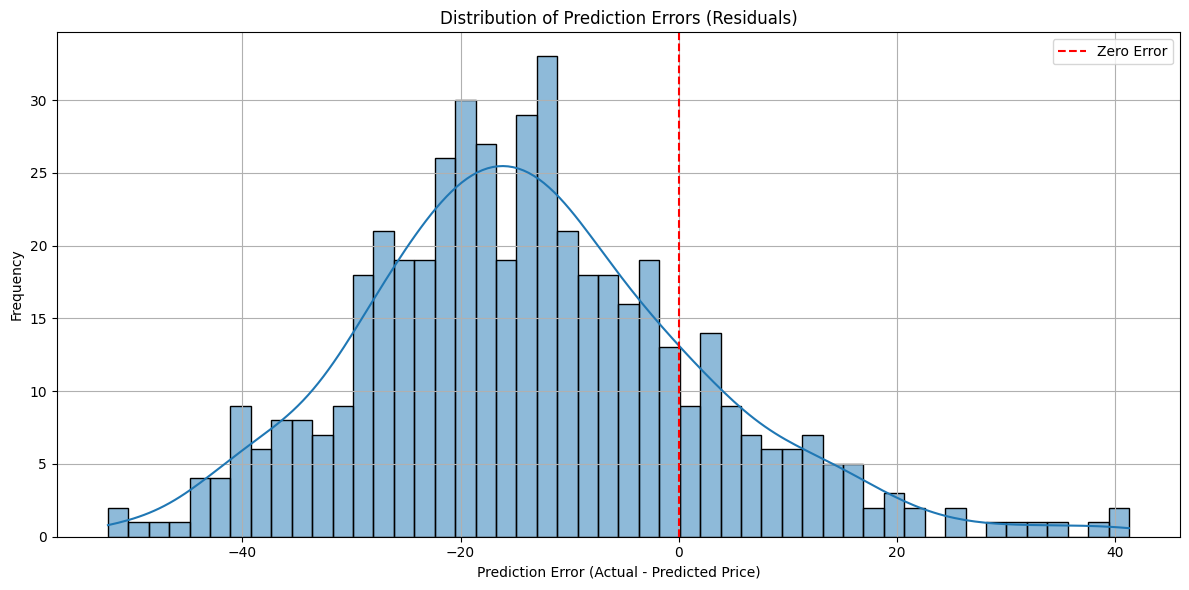

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-make predictions and inverse transform to ensure variables are defined
predictions_fe_scaled = model_fe.predict(X_test, verbose=0)
predictions_fe_inverse_scaled = scaler_y.inverse_transform(predictions_fe_scaled)
y_test_fe_inverse_scaled = scaler_y.inverse_transform(y_test)

# Calculate residuals (prediction errors)
residuals = y_test_fe_inverse_scaled - predictions_fe_inverse_scaled

# Plotting a histogram of residuals
plt.figure(figsize=(12, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Prediction Error (Actual - Predicted Price)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

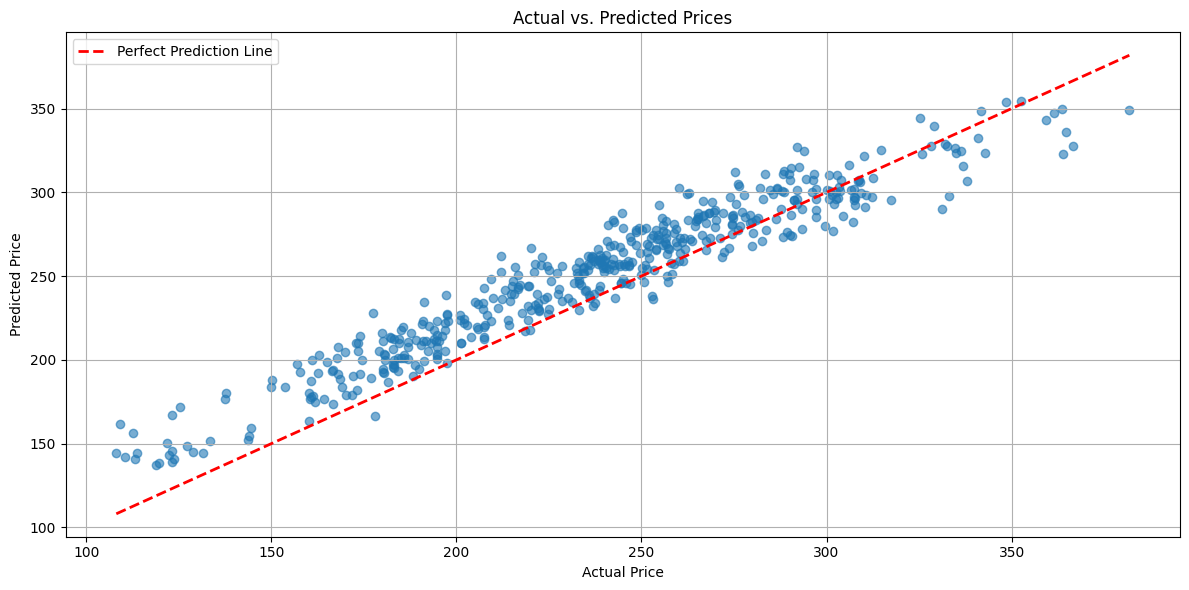

In [18]:
# Re-make predictions and inverse transform to ensure variables are defined
predictions_fe_scaled = model_fe.predict(X_test, verbose=0)
predictions_fe_inverse_scaled = scaler_y.inverse_transform(predictions_fe_scaled)
y_test_fe_inverse_scaled = scaler_y.inverse_transform(y_test)

# Plotting Actual vs. Predicted Values with a Line of Perfect Prediction
plt.figure(figsize=(12, 6))
plt.scatter(y_test_fe_inverse_scaled, predictions_fe_inverse_scaled, alpha=0.6)
plt.plot([y_test_fe_inverse_scaled.min(), y_test_fe_inverse_scaled.max()],
         [y_test_fe_inverse_scaled.min(), y_test_fe_inverse_scaled.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 7.6 Forecasting the Next Trading Day's Price

### 7.7 30-Day Forecast for Tesla Stock Price

### 7.8 Confidence Intervals for 30-Day Forecast

In [22]:
import scipy.stats as st

# Calculate the standard deviation of the residuals from the test set
# residuals were calculated in cell 'a2598107'
std_dev_residuals = np.std(residuals)

# For a 95% confidence interval, the Z-score is approximately 1.96
# You can also use st.norm.ppf(0.975) for a more precise value if needed.
z_score = st.norm.ppf(0.975) # For 95% confidence interval (alpha=0.05, so 1 - alpha/2 = 0.975)

# Calculate upper and lower bounds for the forecast
forecast_df['Lower_Bound_95'] = forecast_df['Forecasted_Close_Price'] - (z_score * std_dev_residuals)
forecast_df['Upper_Bound_95'] = forecast_df['Forecasted_Close_Price'] + (z_score * std_dev_residuals)

print(f"Standard deviation of residuals: {std_dev_residuals:.2f}")
print(f"Z-score for 95% confidence interval: {z_score:.2f}")
print("Forecast DataFrame with 95% Confidence Intervals:")
display(forecast_df.head())
display(forecast_df.tail())

Standard deviation of residuals: 15.47
Z-score for 95% confidence interval: 1.96
Forecast DataFrame with 95% Confidence Intervals:


,Forecasted_Close_Price,Lower_Bound_95,Upper_Bound_95
Date,,,
2024-01-01,271.671539,241.348923,301.994171
2024-01-02,268.707947,238.385330,299.030579
2024-01-03,267.213593,236.890976,297.536224
2024-01-04,266.759979,236.437363,297.082611
2024-01-05,266.734192,236.411575,297.056824


,Forecasted_Close_Price,Lower_Bound_95,Upper_Bound_95
Date,,,
2024-02-05,269.196075,238.873459,299.518707
2024-02-06,269.217896,238.895279,299.540527
2024-02-07,269.236908,238.914291,299.559540
2024-02-08,269.253510,238.930893,299.576141
2024-02-09,269.268066,238.945450,299.590698


In [20]:
import numpy as np
import pandas as pd

num_forecast_days = 30
forecasted_prices = []
forecast_dates = []

# Get the last `look_back` days of data (features) from df_fe.
# This will be our sliding window, converted to a NumPy array for efficiency.
current_features_window_np = df_fe[features].iloc[-look_back:].values.copy()

# Get indices for feature management
feature_names_list = features.tolist()
close_feature_index = feature_names_list.index('close')
lag_feature_indices = {int(col.split('_')[-1]): feature_names_list.index(col) for col in feature_names_list if 'close_lag' in col}

# Identify non-close and non-lagged features
non_close_non_lagged_indices = [
    feature_names_list.index(col) for col in feature_names_list
    if 'close_lag' not in col and col != 'close'
]

# Start date for forecasting
last_known_date = df_fe.index[-1]

print(f"Generating {num_forecast_days}-day forecast...")

for i in range(num_forecast_days):
    # Scale the current window using the fitted scaler_X
    scaled_current_features_window = scaler_X.transform(current_features_window_np)

    # Reshape for LSTM: (1, look_back, num_features)
    reshaped_input = scaled_current_features_window.reshape(1, look_back, -1)

    # Make prediction for the next day
    next_day_prediction_scaled = model_fe.predict(reshaped_input, verbose=0)
    next_day_forecast_unscaled = scaler_y.inverse_transform(next_day_prediction_scaled)[0][0]

    forecasted_prices.append(next_day_forecast_unscaled)

    # Generate the next date, skipping weekends
    next_date = last_known_date + pd.Timedelta(days=1)
    while next_date.weekday() >= 5: # Saturday=5, Sunday=6
        next_date += pd.Timedelta(days=1)
    forecast_dates.append(next_date)
    last_known_date = next_date

    # --- Update current_features_window_np for the next iteration ---
    # Create a new feature vector for the forecasted day
    new_day_feature_vector = np.zeros(len(feature_names_list))

    # 1. Fill non-lagged, non-close features:
    #    Simplification: Use the values from the *last day in the current window* for these features.
    #    This assumes these features remain constant for the forecasted period.
    for col_idx in non_close_non_lagged_indices:
        new_day_feature_vector[col_idx] = current_features_window_np[-1, col_idx]

    # 2. Fill 'close' with the new forecast
    new_day_feature_vector[close_feature_index] = next_day_forecast_unscaled

    # 3. Fill lagged 'close' features:
    #    For close_lag_N, we need the 'close' value from N days prior to 'next_date'.
    #    This means looking back N positions in the `current_features_window_np` array.
    if 1 in lag_feature_indices:
        new_day_feature_vector[lag_feature_indices[1]] = current_features_window_np[-1, close_feature_index]
    if 2 in lag_feature_indices:
        new_day_feature_vector[lag_feature_indices[2]] = current_features_window_np[-2, close_feature_index]
    if 3 in lag_feature_indices:
        new_day_feature_vector[lag_feature_indices[3]] = current_features_window_np[-3, close_feature_index]
    if 5 in lag_feature_indices:
        new_day_feature_vector[lag_feature_indices[5]] = current_features_window_np[-5, close_feature_index]
    if 10 in lag_feature_indices:
        new_day_feature_vector[lag_feature_indices[10]] = current_features_window_np[-10, close_feature_index]

    # Append the new day's feature vector and remove the oldest one from the window
    current_features_window_np = np.vstack([current_features_window_np[1:], new_day_feature_vector])

# Create a DataFrame for the forecast
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Close_Price': forecasted_prices
})
forecast_df.set_index('Date', inplace=True)

display(forecast_df.head())
display(forecast_df.tail())


Generating 30-day forecast...


,Forecasted_Close_Price
Date,
2024-01-01,271.671539
2024-01-02,268.707947
2024-01-03,267.213593
2024-01-04,266.759979
2024-01-05,266.734192


,Forecasted_Close_Price
Date,
2024-02-05,269.196075
2024-02-06,269.217896
2024-02-07,269.236908
2024-02-08,269.253510
2024-02-09,269.268066


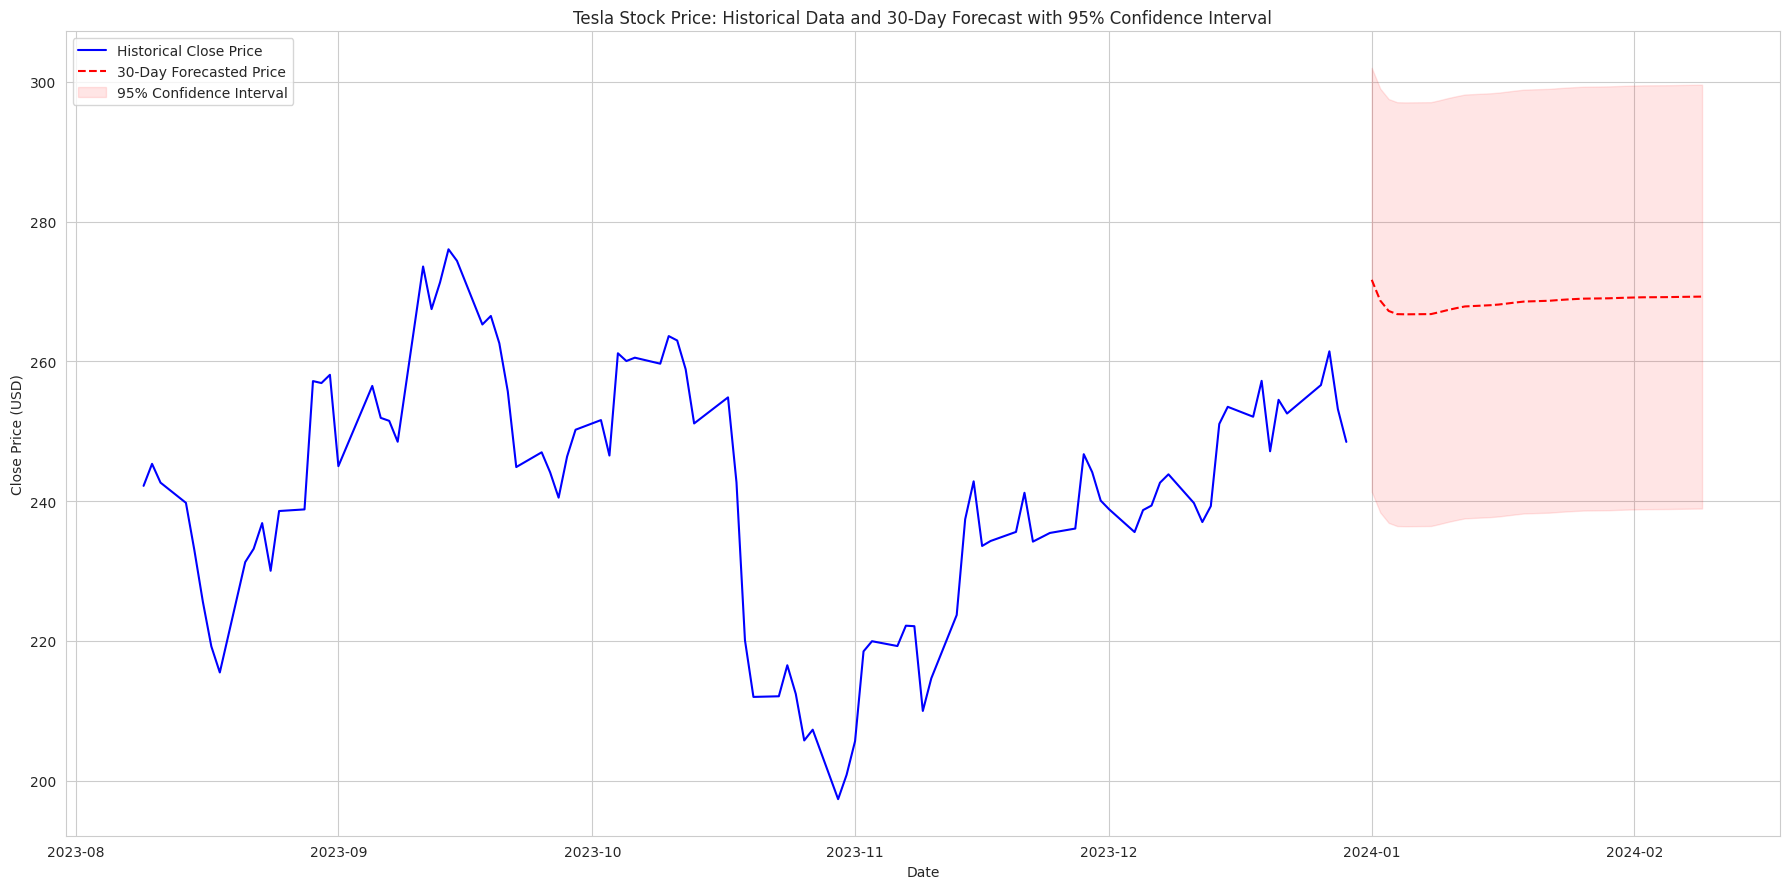

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Combine actual historical close prices and forecasted prices for plotting
historical_data = df_fe['close'].iloc[-100:] # Get last 100 actual close prices for context

plt.figure(figsize=(18, 9))
plt.plot(historical_data.index, historical_data.values, label='Historical Close Price', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecasted_Close_Price'], label='30-Day Forecasted Price', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['Lower_Bound_95'], forecast_df['Upper_Bound_95'], color='red', alpha=0.1, label='95% Confidence Interval')

plt.title('Tesla Stock Price: Historical Data and 30-Day Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np

# Get the last 'look_back' days of data for prediction
# Ensure that the columns match the features used for training
last_look_back_data = df_fe[features].tail(look_back)

# Scale the last 'look_back' data using the trained scaler_X
scaled_last_look_back_data = scaler_X.transform(last_look_back_data)

# Reshape the data to match the LSTM input requirements (samples, timesteps, features)
# Add an extra dimension for 'samples' (which is 1 for a single prediction)
scaled_last_look_back_data = scaled_last_look_back_data.reshape(1, look_back, scaled_last_look_back_data.shape[1])

# Make the prediction using the trained model
next_day_prediction_scaled = model_fe.predict(scaled_last_look_back_data, verbose=0)

# Inverse transform the prediction to get the actual price
next_day_forecast = scaler_y.inverse_transform(next_day_prediction_scaled)

print(f"Forecasted Tesla stock price for the next trading day: ${next_day_forecast[0][0]:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Forecasted Tesla stock price for the next trading day: $271.67


## Variable Description and Summary Statistics

This section provides a detailed description of each variable in the dataset, including its data type and what it represents. We will also look at the summary statistics to understand the central tendency, dispersion, and shape of the distribution of each column.

### Variable Descriptions:

*   **date**: Date of the stock trading day. (Already converted to DatetimeIndex)
*   **open**: The price at which the stock started trading at the beginning of the trading day.
*   **high**: The highest price the stock reached during the trading day.
*   **low**: The lowest price the stock reached during the trading day.
*   **close**: The price at which the stock ended trading at the close of the trading day.
*   **volume**: The total number of shares traded during the day.
*   **rsi_7**: Relative Strength Index over 7 periods. A momentum indicator used in technical analysis.
*   **rsi_14**: Relative Strength Index over 14 periods.
*   **cci_7**: Commodity Channel Index over 7 periods. An oscillator used to identify new trends or warn of extreme conditions.
*   **cci_14**: Commodity Channel Index over 14 periods.
*   **sma_50**: Simple Moving Average over 50 periods. Used to identify trends.
*   **ema_50**: Exponential Moving Average over 50 periods. Gives more weight to recent prices.
*   **sma_100**: Simple Moving Average over 100 periods.
*   **ema_100**: Exponential Moving Average over 100 periods.
*   **macd**: Moving Average Convergence Divergence. A trend-following momentum indicator.
*   **bollinger**: Bollinger Bands. A volatility indicator.
*   **TrueRange**: True Range. Measures market volatility.
*   **atr_7**: Average True Range over 7 periods. Measures market volatility.
*   **atr_14**: Average True Range over 14 periods.
*   **next_day_close**: The closing price of the stock on the next trading day (our target variable).

In [11]:
# Display summary statistics for numerical columns
display(df.describe())

,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000
mean,94.098510,96.172733,91.865096,94.072491,1.131986e+08,53.058382,52.862457,9.809933,13.202457,91.810735,91.806751,89.542873,89.547927,0.647230,93.162246,4.699351,4.680234,4.656461,94.167250
std,108.593936,111.022486,105.911918,108.500301,7.547433e+07,18.239752,13.352063,100.975002,109.285239,106.581797,106.094893,104.809940,103.979872,6.325994,107.718086,6.581929,5.858869,5.762082,108.530957
min,9.366667,9.800000,9.111333,9.289333,1.062000e+07,6.395305,16.564126,-233.333333,-297.930166,9.490973,9.813725,10.494240,9.674284,-25.271333,9.740800,0.135334,0.257427,0.315794,9.289333
25%,15.763167,16.082168,15.491167,15.814167,6.643185e+07,39.859440,43.595435,-76.876737,-78.543937,15.496080,15.446697,15.356488,15.594446,-0.392822,15.733792,0.496333,0.569335,0.577166,15.822167
50%,21.801001,22.198334,21.487666,21.877667,9.320775e+07,53.226417,51.621434,19.823624,24.702835,21.563733,21.575870,21.106043,21.195890,0.098391,21.859567,0.894002,0.833601,0.805047,21.881334
75%,200.017505,204.525829,194.482498,200.049999,1.323710e+08,65.900330,61.937068,94.426550,99.180514,192.341650,196.465729,194.728575,194.154595,1.094057,199.300335,7.700836,9.021824,9.291728,200.844997
max,411.470001,414.496674,405.666656,409.970001,9.140820e+08,97.460910,94.197983,233.333333,350.643337,357.870532,344.030730,330.935132,321.063883,38.067930,373.152498,54.326660,24.512656,22.793229,409.970001
